In [71]:
import sys

project_root = 'c:/big20/git/big20-ML-project2-team3/CreditCardFraud'

# sys.path에 추가 (모듈 import용)
if project_root not in sys.path:
    sys.path.insert(0, project_root)

In [72]:
import pandas as pd
import numpy  as np
from scipy.special import logit
import time
import warnings
warnings.filterwarnings("ignore")
from pathlib import Path
import math

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, roc_curve, classification_report, confusion_matrix, recall_score, precision_score
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials

import matplotlib
import matplotlib.pyplot as plt
plt.rcParams['font.family'] ='Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False
import seaborn as sns

import importlib
from utils import preprocessing
importlib.reload(preprocessing) # 모듈 reload
# importlib.reload(user_utils)

import utils.preprocessing as pp
import utils.user_utils    as uu
import utils.model_utils   as mu
import utils.evaluation    as ev
import utils.modeling      as mo
import utils.data_sampling as ds

# train = pd.read_csv("../data/train.csv")
# test  = pd.read_csv("../data/test.csv")

In [73]:
# 1) 원본 데이터
df = pp.ccf_load_data("../data/creditcard.csv")  # 원본: Time, Amount 포함

데이터 로드 성공: (284807, 31)


 결측치 정보 ======================================================================
✅ 결측치 없음

== 타겟 분포 ======================================================================

[Class] 개수:
Class
0    284315
1       492
Name: count, dtype: int64

[Class] 비율(%):
  Class 0: 99.83%
  Class 1: 0.17%
  ⚠️ 심각한 불균형 (0.17%)


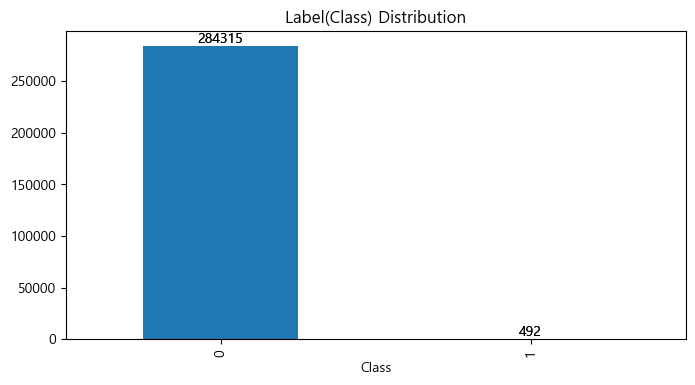

In [74]:
# 기본정보 확인
pp.checkBasicInfo(df, isInfo=False)

In [75]:
df.describe() # 1행이 신용카드 1건이다 # 이게 과제다. 어떤 컬럼을 어떻게 볼 것인가!

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [76]:
# 데이터가 심하게 불균형일때 일반화 성능이 떨어짐
# 이때 over sampling(큰쪽으로 작은 데이터를 만들어 늘리는 것 - 증식) => 주로 사용함. 데이터가 늘어 남
# => 늘이는 방법 : feature를 줄여서 차원을 축소(신용카드 30개 features -> 2개로 줄이고), K-NN 으로 증식 => 어쨋든 오차가 존재하게된다!
# under sampling (원래 있는 큰 데이터를 작은쪽에 맞게 줄이게) => 데이터가 줄어드니까~

In [77]:
# 2025.11.10.월. 1교시
# AutoEncoder : 생성형AI 중심 (D.L) => 데이터 생성, over sampling 데이터 증식할 때 사용, 잘 봐야한다!!! 뒤에서 다시 설명한끄야~
# M.L : KNN

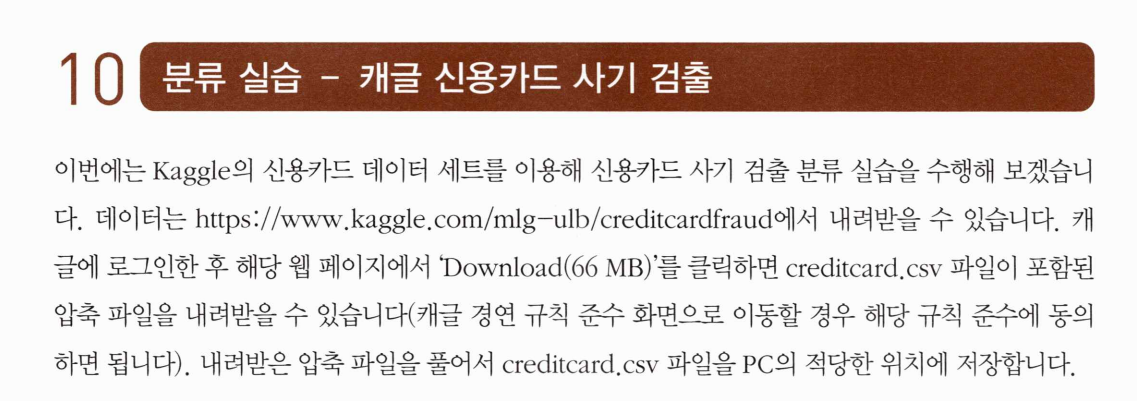
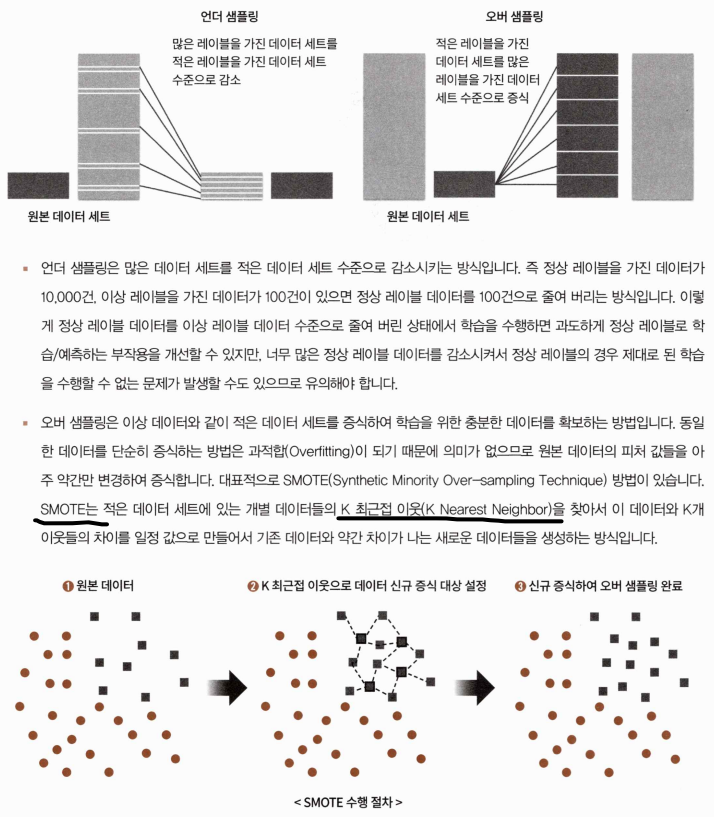

In [78]:
df['Amount'].describe()

count    284807.000000
mean         88.349619
std         250.120109
min           0.000000
25%           5.600000
50%          22.000000
75%          77.165000
max       25691.160000
Name: Amount, dtype: float64

In [79]:
df['Time'].describe()

count    284807.000000
mean      94813.859575
std       47488.145955
min           0.000000
25%       54201.500000
50%       84692.000000
75%      139320.500000
max      172792.000000
Name: Time, dtype: float64

In [80]:
# RobustScaler는 이상치(극단값)에 덜 민감한 스케일링 방법
# 극단적으로 큰 결제금액 몇 개가 있어도 대부분 데이터의 스케일이 덜 왜곡
# **금액(Amount)**처럼 분포가 심하게 한쪽으로 치우치고,
# **시간(Time)**처럼 범위가 크고 이상치가 있을 수 있는 컬럼에 쓴다.

df_scaled = pp.robustScaler(df)

✅ 'Amount' 스케일링 완료 → 'Amount_scaled'
✅ 'Time' 스케일링 완료 → 'Time_scaled'

🗑️  원본 컬럼 제거: ['Amount', 'Time']

✅ 스케일링 완료: 2개 컬럼
   최종 shape: (284807, 31)


In [81]:
print(df_scaled.head())
print(df_scaled.describe().T[['mean', 'std', 'min', '25%', '50%', '75%', 'max']])

# Class 비율 다시 확인 (확인 차원)
print(df_scaled['Class'].value_counts())
print(df_scaled['Class'].value_counts(normalize=True))

         V1        V2        V3        V4        V5        V6        V7  \
0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9       V10  ...       V22       V23       V24       V25  \
0  0.098698  0.363787  0.090794  ...  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425 -0.166974  ... -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  0.207643  ...  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024 -0.054952  ...  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  0.753074  ...  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28  Class  Amount_scaled  Time_scaled  

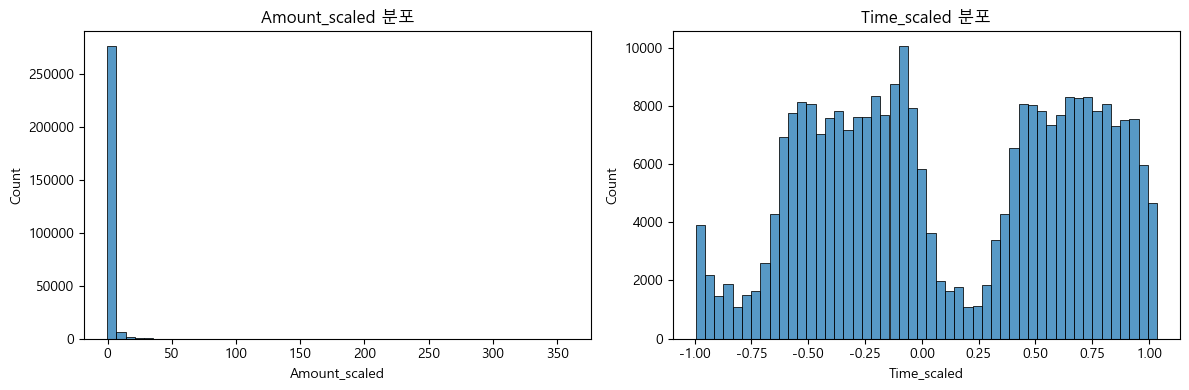

In [82]:
# Amount_scaled, Time_scaled : 해석 가능한 거의 유일한 원본 피처들

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
sns.histplot(df_scaled['Amount_scaled'], bins=50)
plt.title('Amount_scaled 분포')

plt.subplot(1, 2, 2)
sns.histplot(df_scaled['Time_scaled'], bins=50)
plt.title('Time_scaled 분포')

plt.tight_layout()
plt.show()

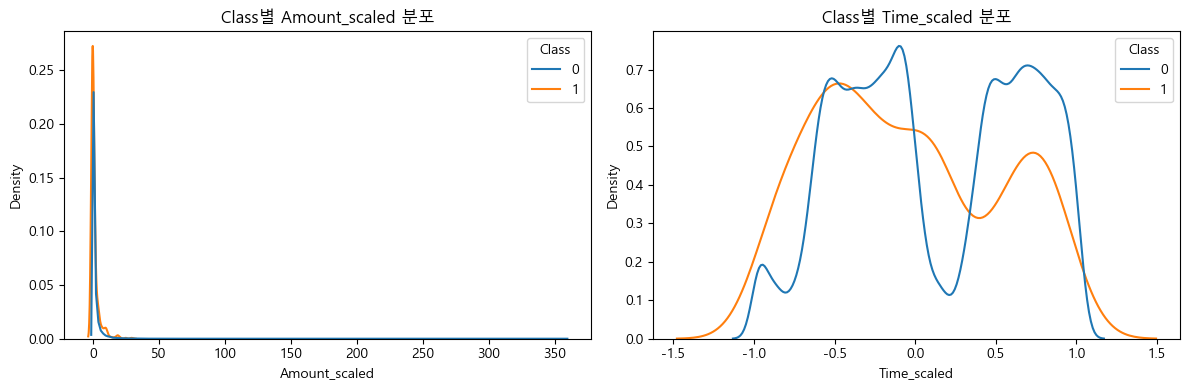

In [83]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.kdeplot(
    data=df_scaled,
    x='Amount_scaled',
    hue='Class',
    common_norm=False
)
plt.title('Class별 Amount_scaled 분포')

plt.subplot(1, 2, 2)
sns.kdeplot(
    data=df_scaled,
    x='Time_scaled',
    hue='Class',
    common_norm=False
)
plt.title('Class별 Time_scaled 분포')

plt.tight_layout()
plt.show()

# 시간대에 따라 사기 비율이 다를 가능성”은 있어 보임.

In [84]:
stats = df_scaled.groupby('Class')[['Amount_scaled', 'Time_scaled']].describe().T
print(stats)

Class                            0           1
Amount_scaled count  284315.000000  492.000000
              mean        0.926305    1.400284
              std         3.494796    3.586715
              min        -0.307413   -0.307413
              25%        -0.228464   -0.293440
              50%         0.000000   -0.178160
              75%         0.769231    1.172221
              max       358.683155   29.398030
Time_scaled   count  284315.000000  492.000000
              mean        0.119200   -0.046349
              std         0.557854    0.561982
              min        -0.994983   -0.990214
              25%        -0.357875   -0.510468
              50%         0.000223   -0.107185
              75%         0.641937    0.514468
              max         1.035022    1.006309


Class            1.000000
V11              0.154876
V4               0.133447
V2               0.091289
V21              0.040413
V19              0.034783
V20              0.020090
V8               0.019875
V27              0.017580
V28              0.009536
Amount_scaled    0.005632
V26              0.004455
V25              0.003308
V22              0.000805
V23             -0.002685
V15             -0.004223
V13             -0.004570
V24             -0.007221
Time_scaled     -0.012323
V6              -0.043643
V5              -0.094974
V9              -0.097733
V1              -0.101347
V18             -0.111485
V7              -0.187257
V3              -0.192961
V16             -0.196539
V10             -0.216883
V12             -0.260593
V14             -0.302544
V17             -0.326481
Name: Class, dtype: float64


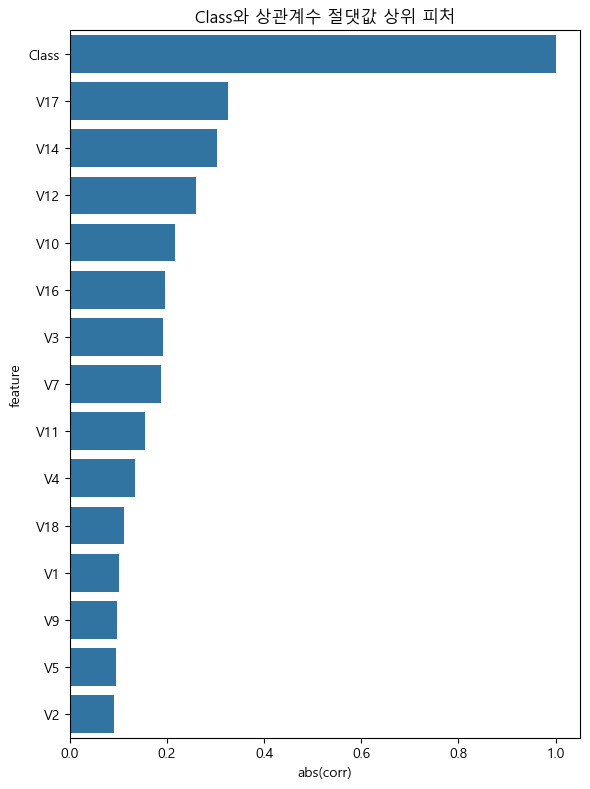

In [85]:
# 상관계수 계산
corr = df_scaled.corr()['Class'].sort_values(ascending=False)
print(corr)

# 절댓값 상위 피처만 시각화
top_corr = corr.abs().sort_values(ascending=False).head(15)

plt.figure(figsize=(6, 8))
sns.barplot(
    x=top_corr.values,
    y=top_corr.index
)
plt.title('Class와 상관계수 절댓값 상위 피처')
plt.xlabel('abs(corr)')
plt.ylabel('feature')
plt.tight_layout()
plt.show()

# 이 피처들이 다른 애들보다 사기 여부와 더 강하게 연관돼 있다는 뜻
# 나중에 모델링/설명할 때 “주요 피처 후보”가 될 수 있음

In [86]:
cols_basic = ['Amount_scaled', 'Time_scaled']
df_scaled.groupby('Class')[cols_basic].describe().T

Class                            0           1
Amount_scaled count  284315.000000  492.000000
              mean        0.926305    1.400284
              std         3.494796    3.586715
              min        -0.307413   -0.307413
              25%        -0.228464   -0.293440
              50%         0.000000   -0.178160
              75%         0.769231    1.172221
              max       358.683155   29.398030
Time_scaled   count  284315.000000  492.000000
              mean        0.119200   -0.046349
              std         0.557854    0.561982
              min        -0.994983   -0.990214
              25%        -0.357875   -0.510468
              50%         0.000223   -0.107185
              75%         0.641937    0.514468
              max         1.035022    1.006309

In [87]:
# 상위 top5 피처
top_feats = ['V17', 'V14', 'V12', 'V10', 'V16']
df_scaled.groupby('Class')[top_feats].describe().T

Class                  0           1
V17 count  284315.000000  492.000000
    mean        0.011535   -6.665836
    std         0.749457    6.970618
    min       -17.098444  -25.162799
    25%        -0.482644  -11.945057
    50%        -0.064833   -5.302949
    75%         0.399922   -1.341940
    max         9.253526    6.739384
V14 count  284315.000000  492.000000
    mean        0.012064   -6.971723
    std         0.897007    4.278940
    min       -18.392091  -19.214325
    25%        -0.422453   -9.692723
    50%         0.051947   -6.729720
    75%         0.494104   -4.282821
    max        10.526766    3.442422
V12 count  284315.000000  492.000000
    mean        0.010832   -6.259393
    std         0.945939    4.654458
    min       -15.144988  -18.683715
    25%        -0.402102   -8.688177
    50%         0.141679   -5.502530
    75%         0.619207   -2.974088
    max         7.848392    1.375941
V10 count  284315.000000  492.000000
    mean        0.009824   -5.676883
    std         1.044204    4.897341
    min       -14.741096  -24.588262
    25%        -0.532880   -7.756698
    50%        -0.091872   -4.578825
    75%         0.455135   -2.614184
    max        23.745136    4.031435
V16 count  284315.000000  492.000000
    mean        0.007164   -4.139946
    std         0.844772    3.865035
    min       -10.115560  -14.129855
    25%        -0.465543   -6.562915
    50%         0.067377   -3.549795
    75%         0.523738   -1.226043
    max        17.315112    3.139656

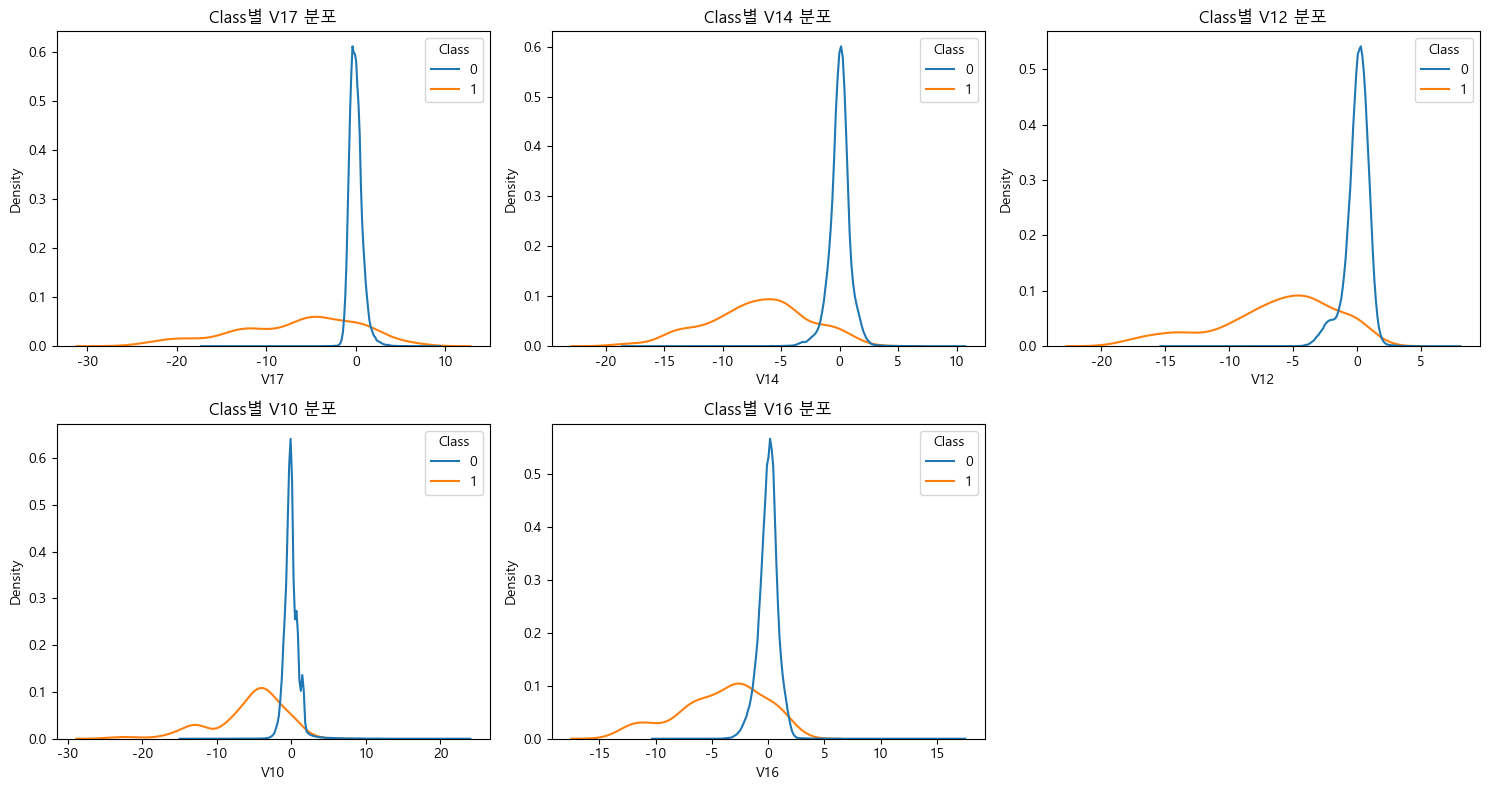

In [88]:
# 상관 상위 피처들에 대해 Class별 분포 보기

top_feats = ['V17', 'V14', 'V12', 'V10', 'V16']

plt.figure(figsize=(15, 8))
for i, col in enumerate(top_feats, 1):
    plt.subplot(2, 3, i)
    sns.kdeplot(data=df_scaled, x=col, hue='Class', common_norm=False)
    plt.title(f'Class별 {col} 분포')
plt.tight_layout()
plt.show()


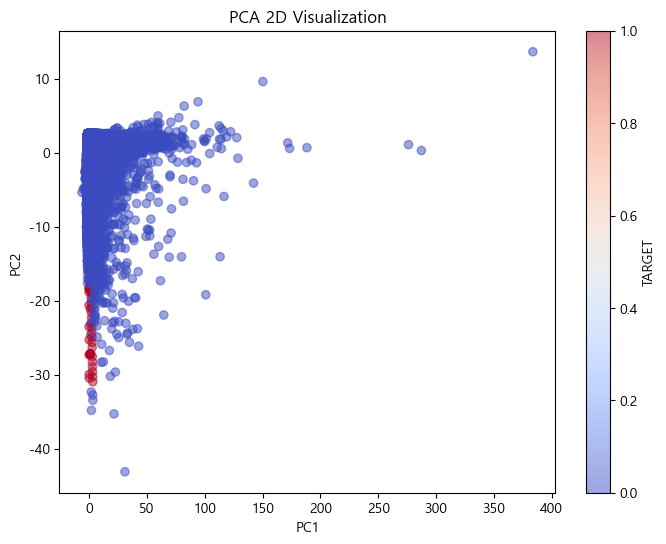

In [89]:
# PCA 2D 시각화
# 전체 피처 조합 기준으로 Class가 얼마나 섞여 있는지!

from sklearn.decomposition import PCA
from utils.evaluation import plot_pca_2d

X = df_scaled.drop('Class', axis=1)
y = df_scaled['Class']

pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X)

plot_pca_2d(X_2d, y)


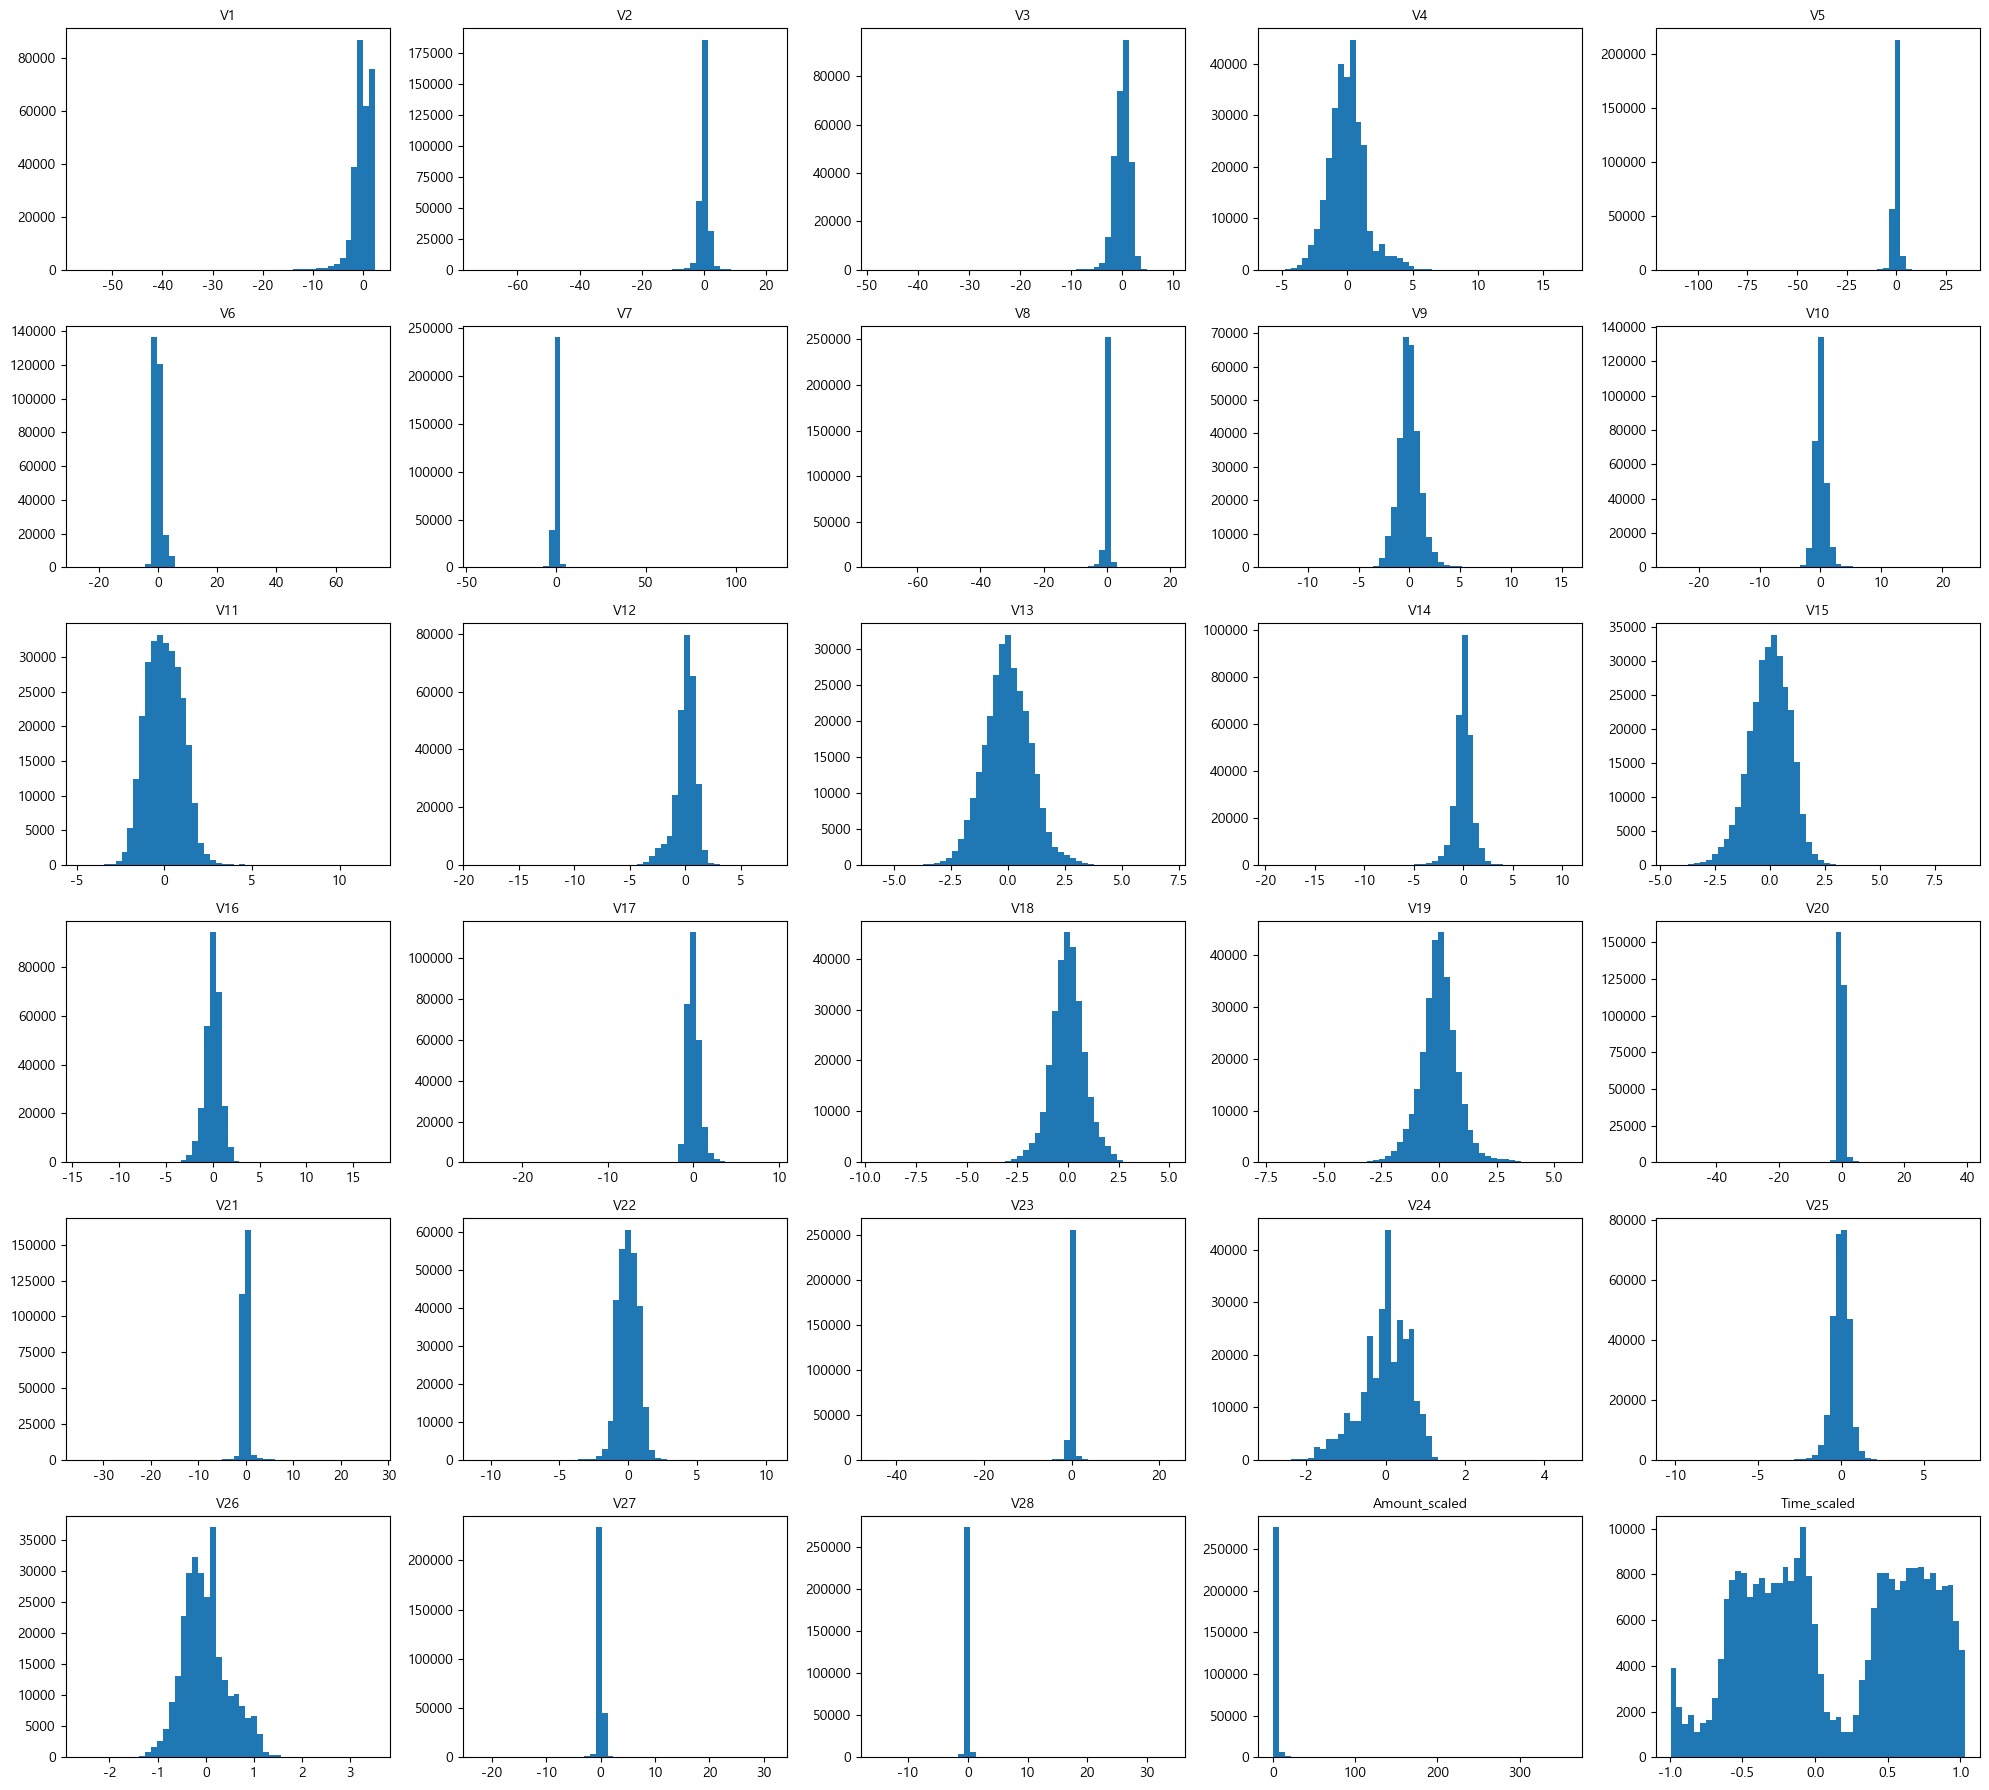

In [90]:
# Class 제외한 모든 피처
# 전체 피처 히스토그램 (원본 스케일 그대로, 이상치 포함)
feature_cols = [c for c in df_scaled.columns if c != 'Class']

n_cols = 5   # 한 줄에 5개씩
n_rows = (len(feature_cols) + n_cols - 1) // n_cols  # 필요한 행 수

plt.figure(figsize=(n_cols * 4, n_rows * 3))

for i, col in enumerate(feature_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    plt.hist(df_scaled[col], bins=50)
    plt.title(col, fontsize=10)
    plt.tight_layout()

plt.show()

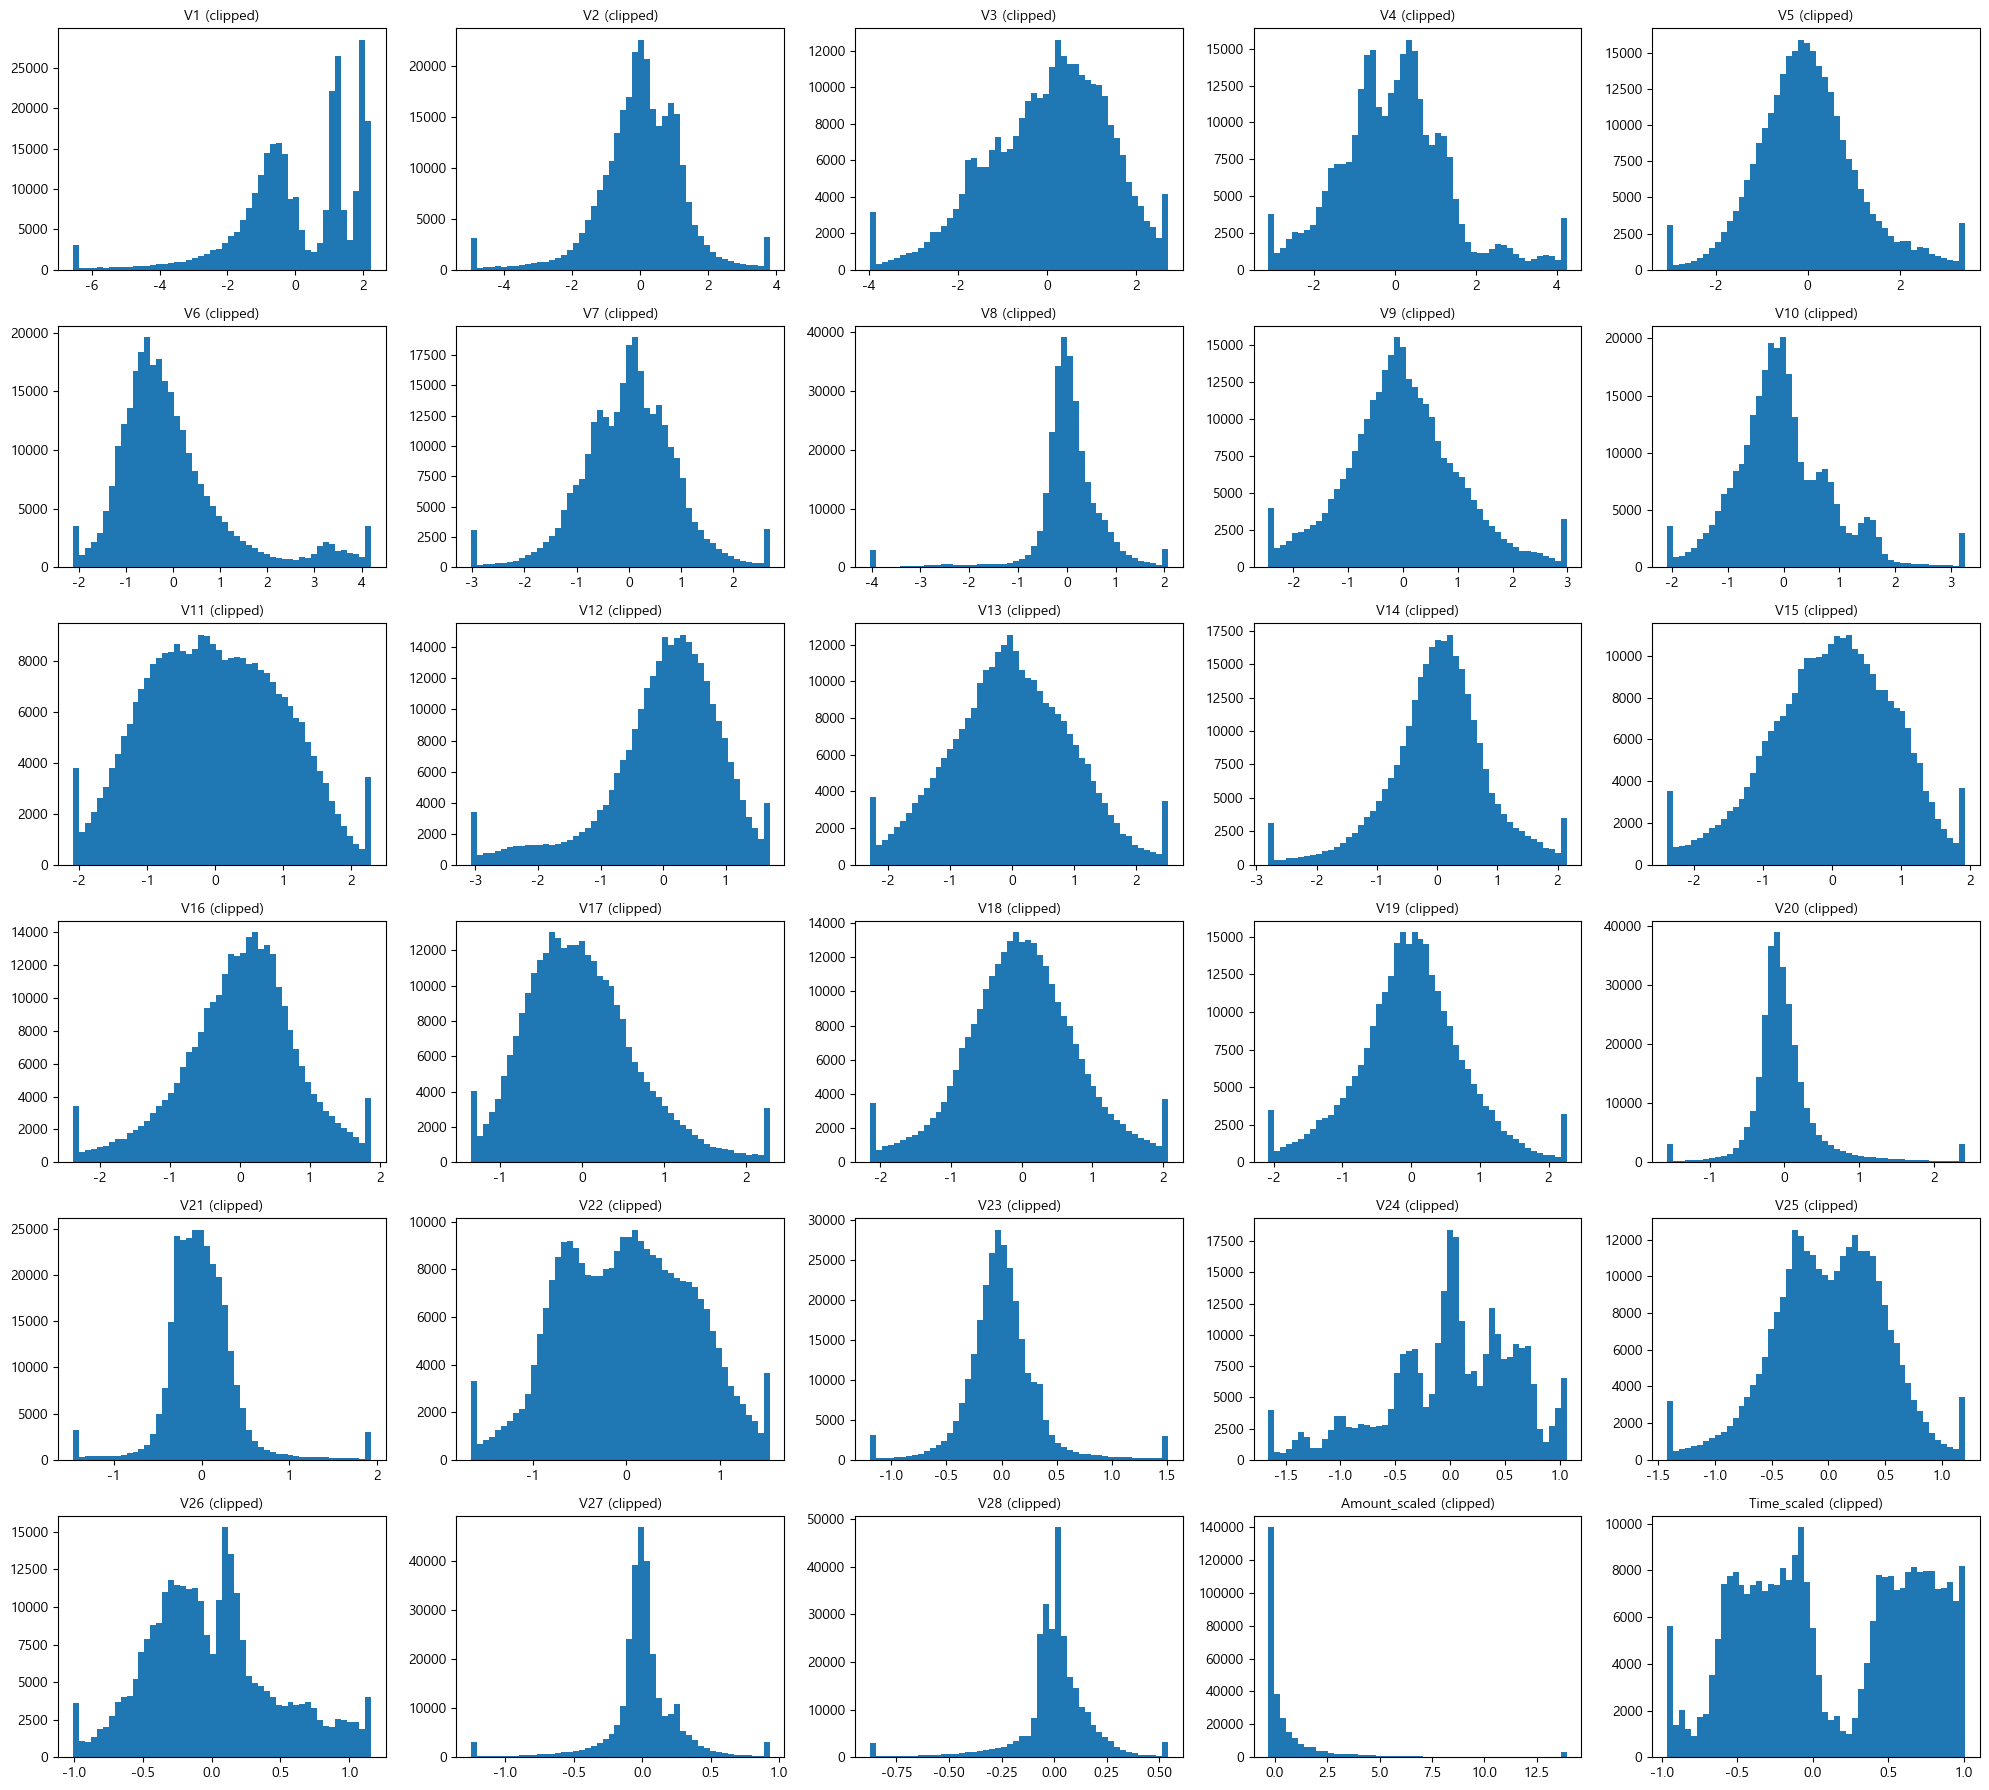

In [91]:
feature_cols = [c for c in df_scaled.columns if c != 'Class']

# 시각화용 복사본
df_clip = df_scaled.copy()

# 이상치 영향 줄인 히스토그램 (클리핑해서 보기)
# 각 피처별로 1%~99% 구간으로 클리핑
for col in feature_cols:
    q01 = df_clip[col].quantile(0.01)
    q99 = df_clip[col].quantile(0.99)
    df_clip[col] = df_clip[col].clip(lower=q01, upper=q99)

n_cols = 5
n_rows = (len(feature_cols) + n_cols - 1) // n_cols

plt.figure(figsize=(n_cols * 4, n_rows * 3))

for i, col in enumerate(feature_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    plt.hist(df_clip[col], bins=50)
    plt.title(col + " (clipped)", fontsize=10)
    plt.tight_layout()

plt.show()

In [92]:
# 사기 거래만 필터링
df_fraud = df_scaled[df_scaled['Class'] == 1].copy()
print(df_fraud.shape)   # (사기 거래 개수, 31)

(492, 31)


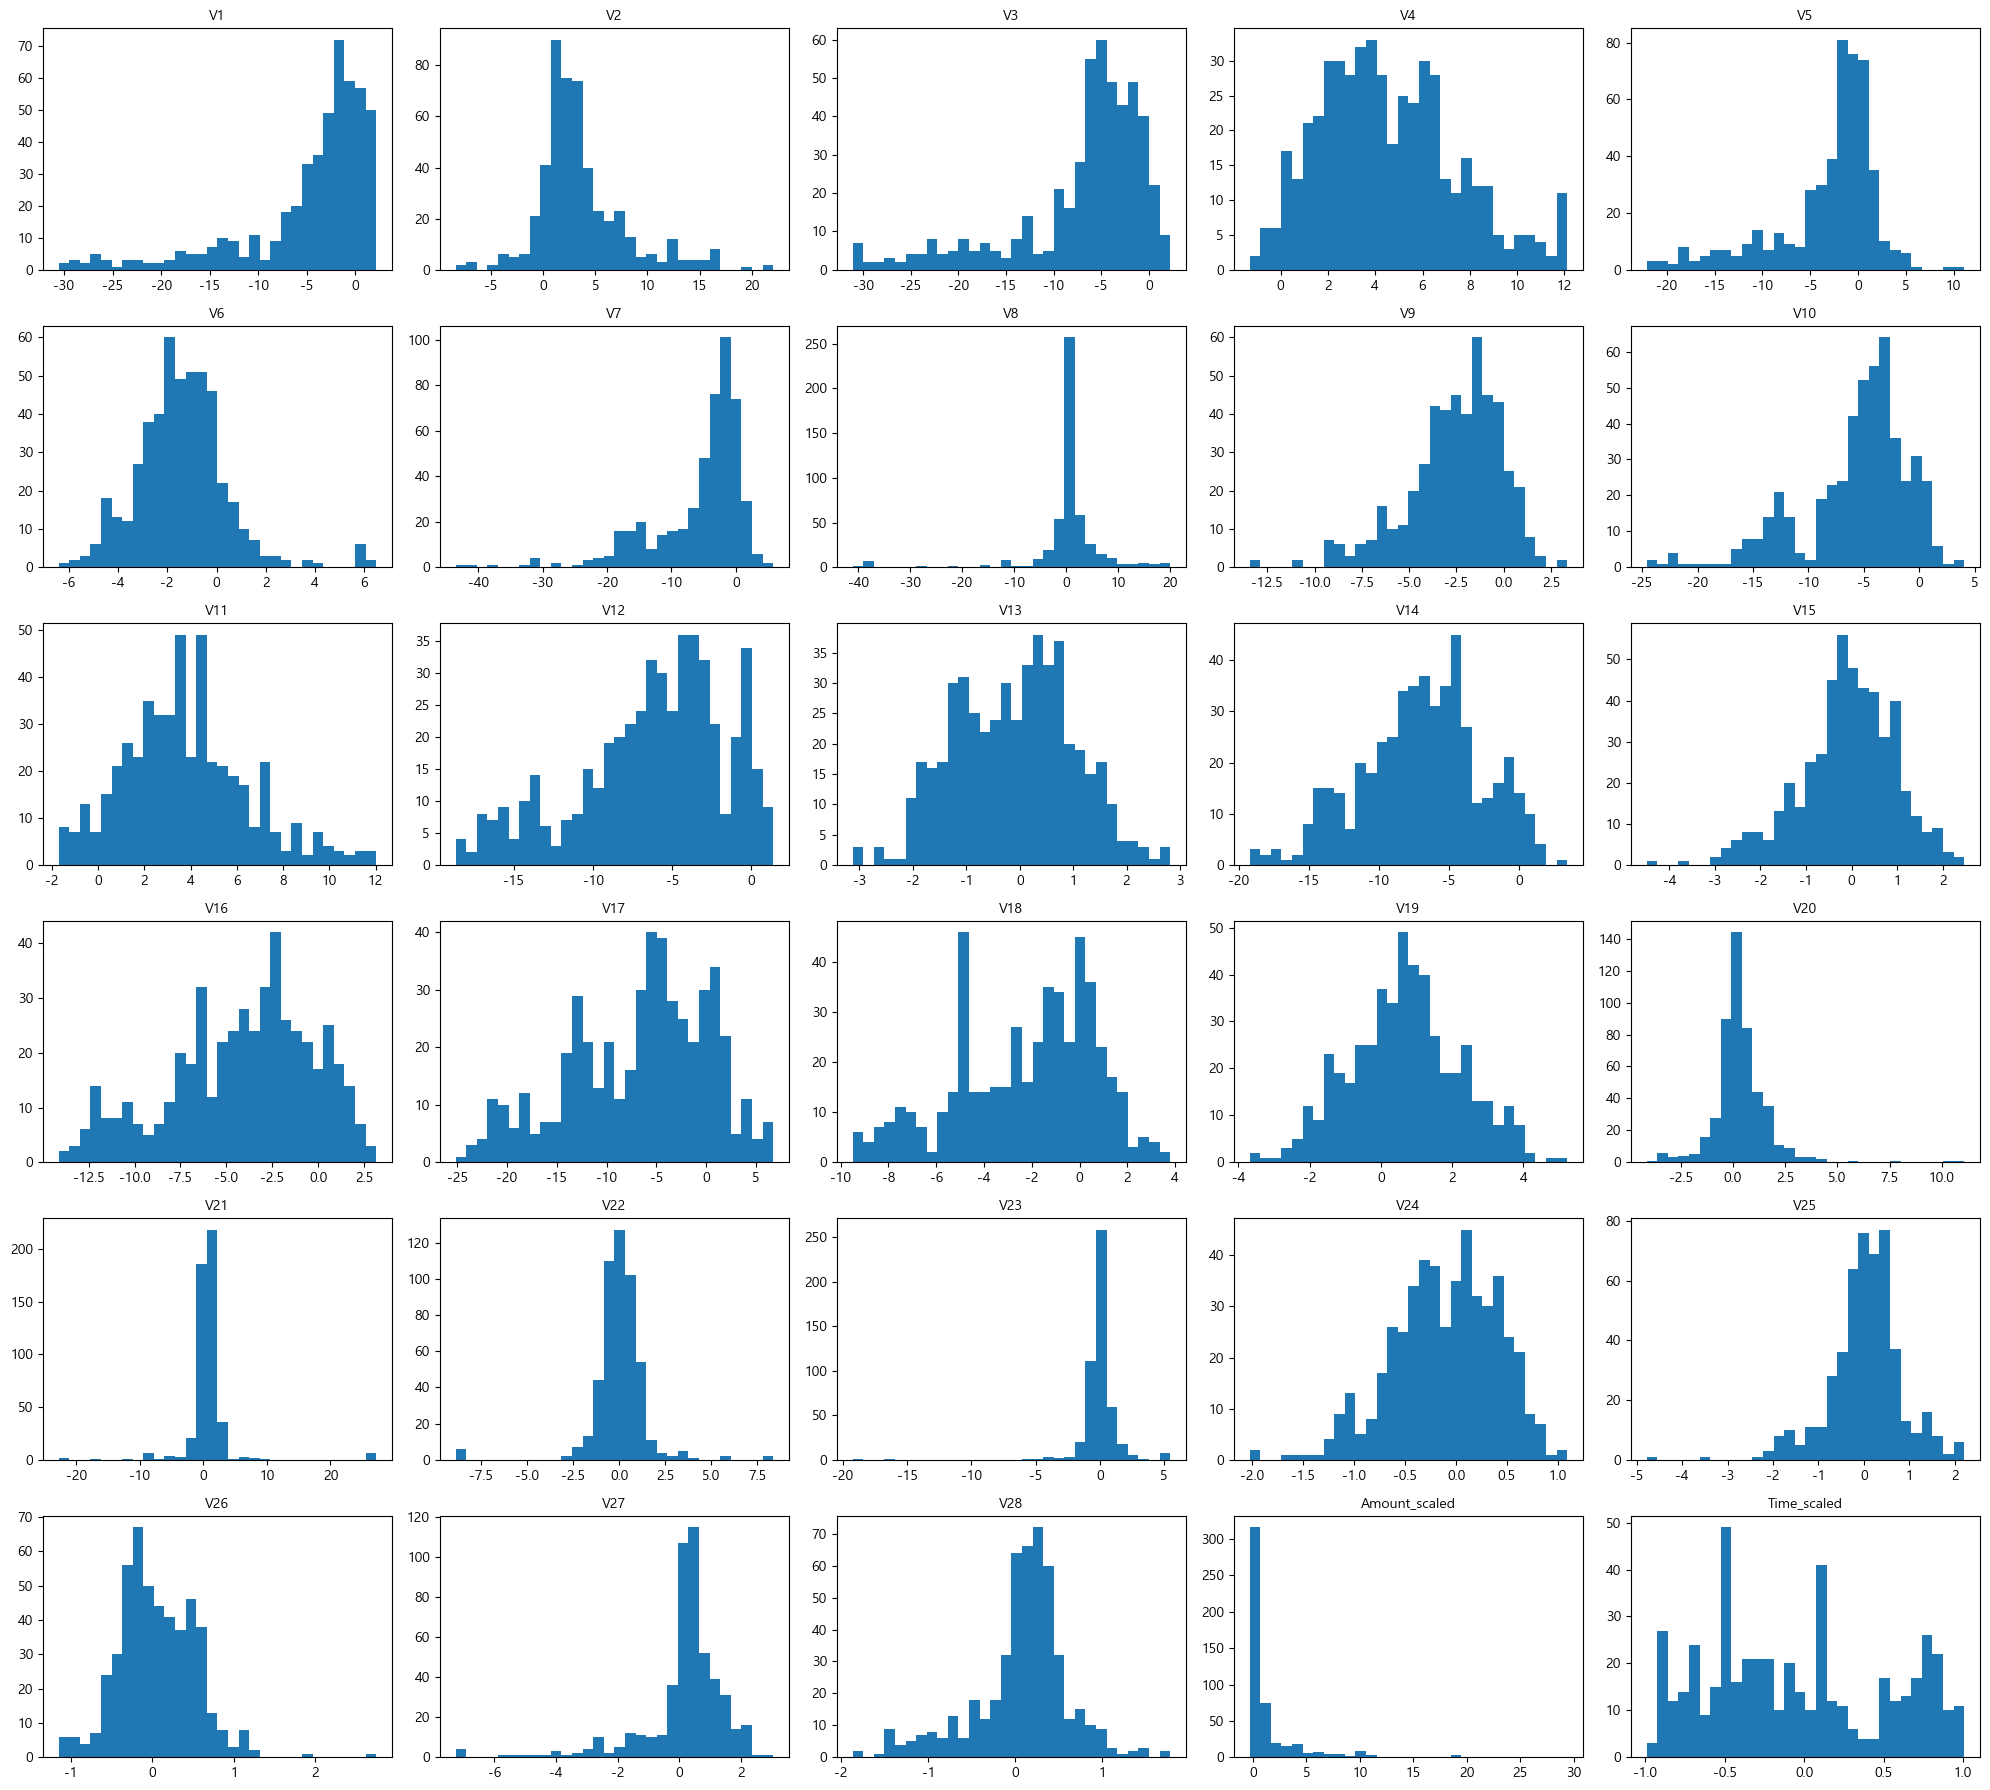

In [93]:
# Class = 1
# df_fraud = df_scaled[df_scaled['Class'] == 1].copy()
feature_cols = [c for c in df_fraud.columns if c != 'Class']

n_cols = 5
n_rows = (len(feature_cols) + n_cols - 1) // n_cols

plt.figure(figsize=(n_cols * 4, n_rows * 3))

for i, col in enumerate(feature_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    plt.hist(df_fraud[col], bins=30)   # 사기 데이터가 적어서 bin 수는 조금 줄임
    plt.title(col, fontsize=10)
    plt.tight_layout()

plt.show()

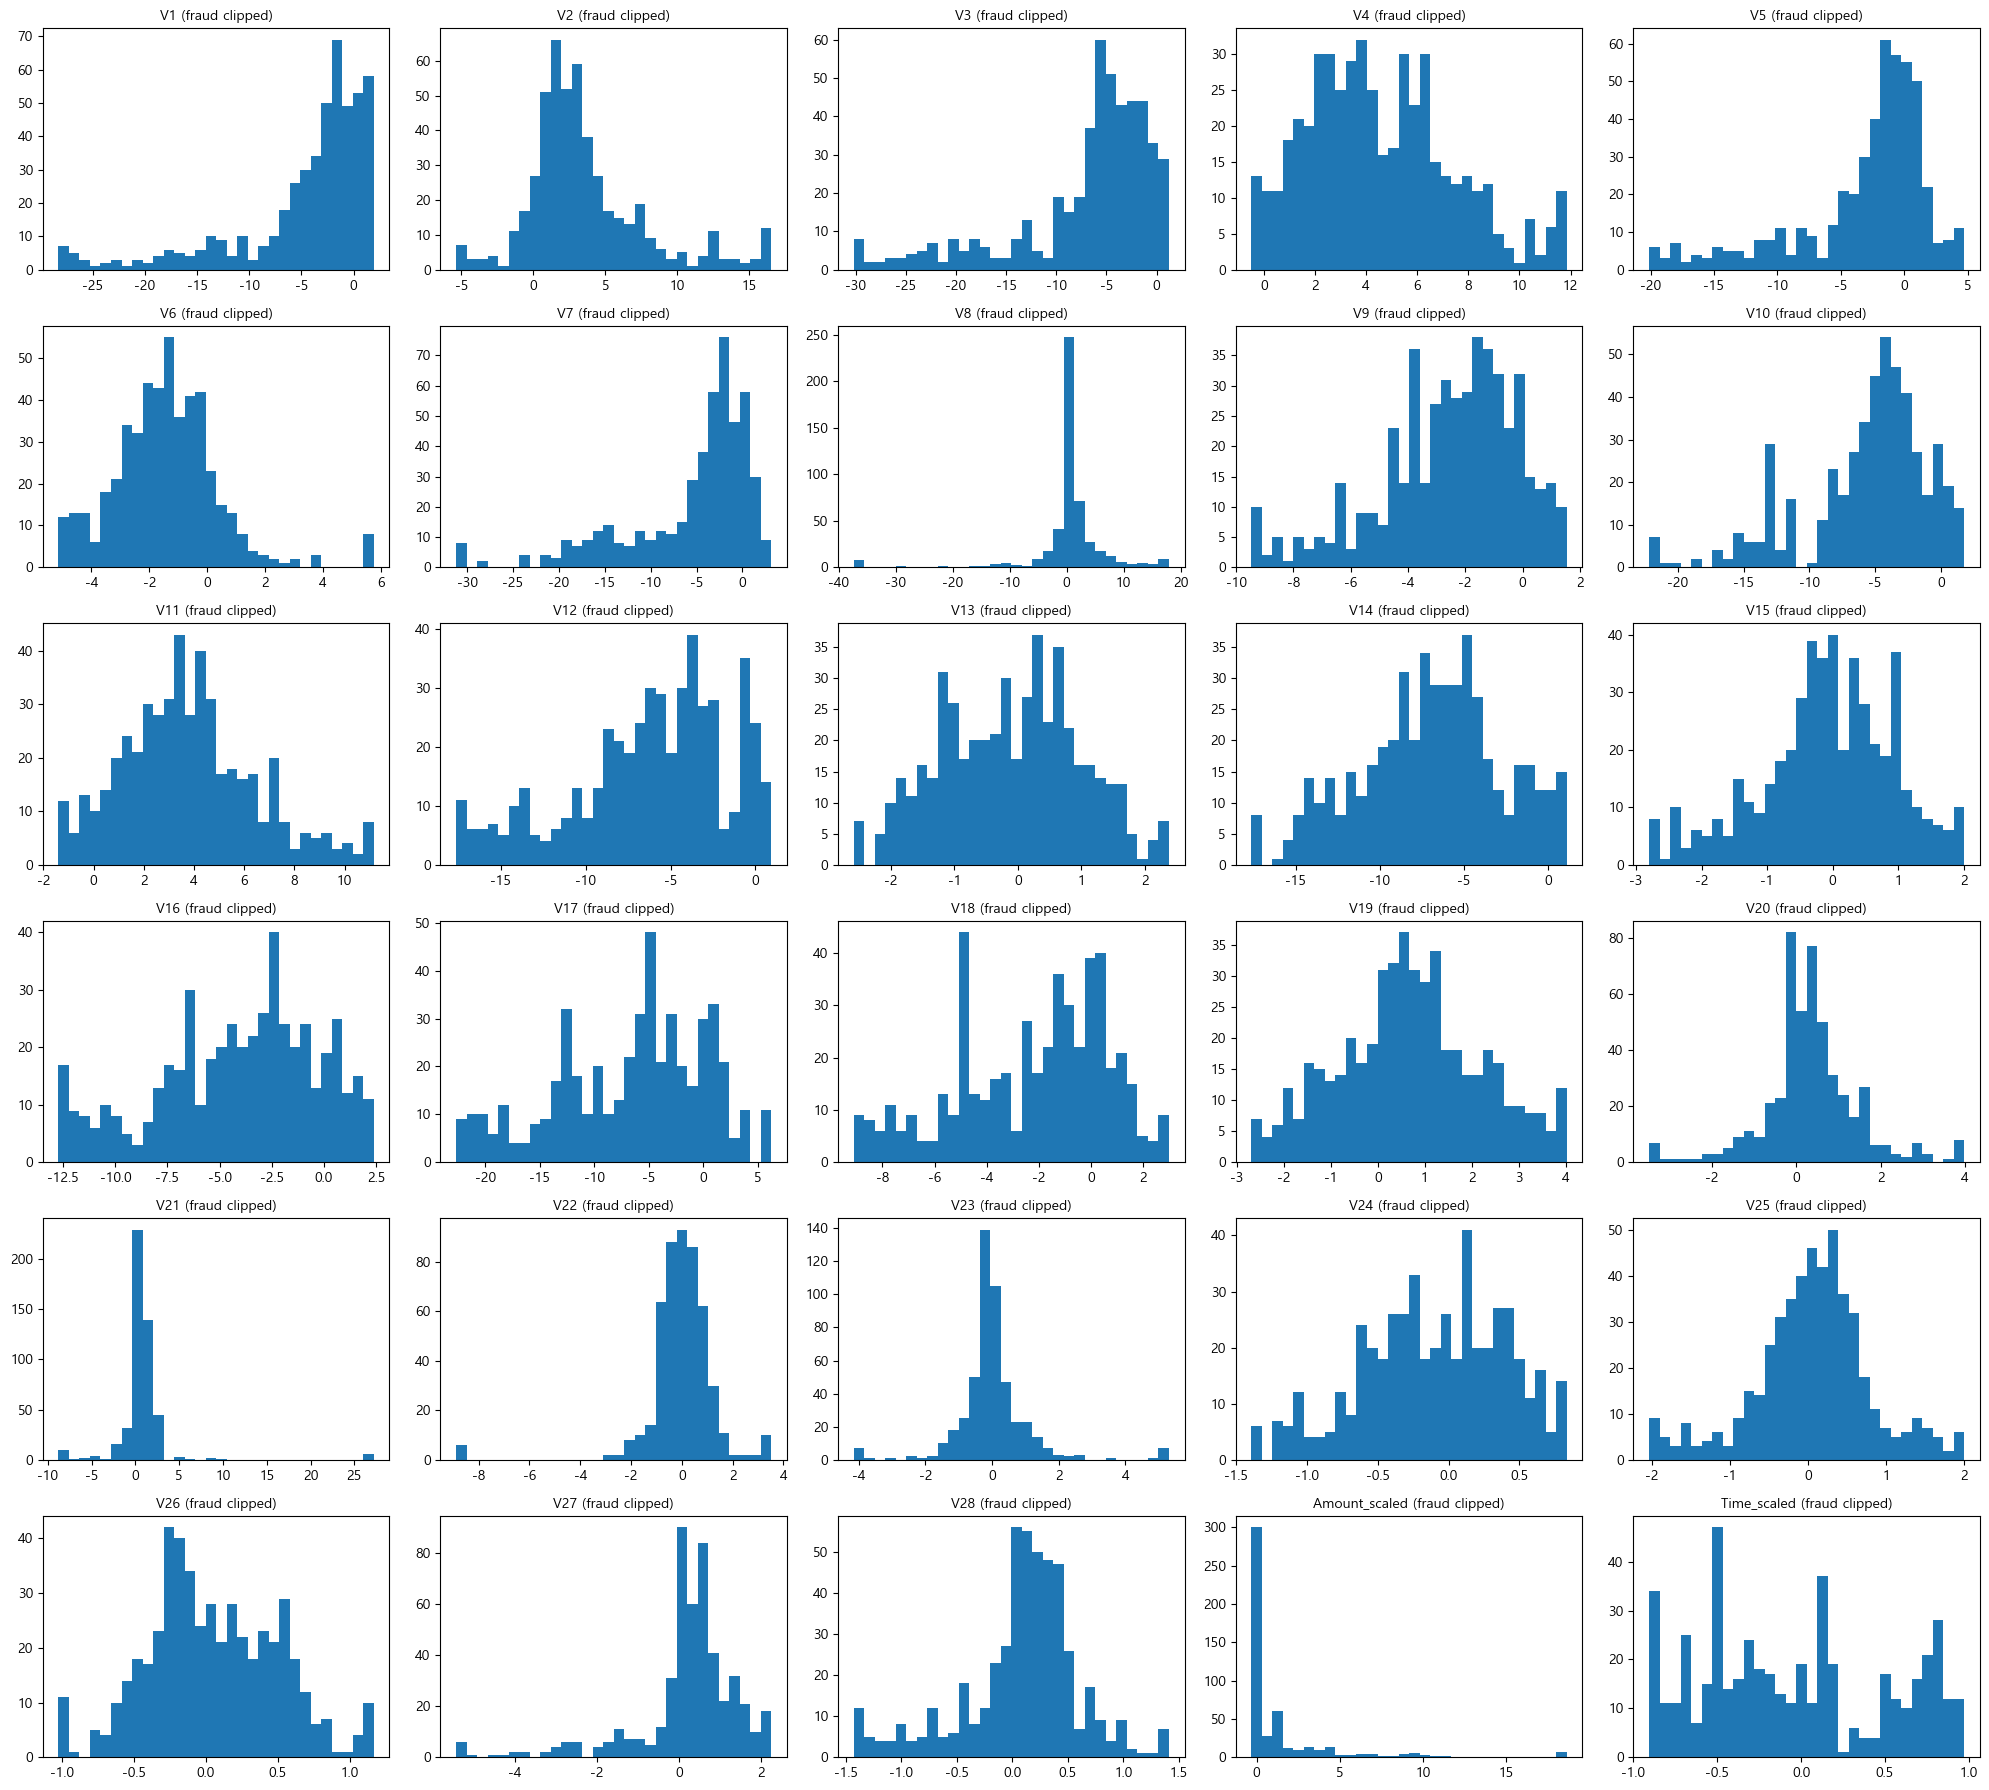

In [94]:
# Class = 1 대상으로 이상치 영향 줄인 히스토그램 (클리핑)
# 각 피처별로 1%~99% 구간으로 클리핑
df_fraud_clip = df_fraud.copy()
feature_cols = [c for c in df_fraud_clip.columns if c != 'Class']

# 각 피처별 1%~99% 구간으로 클리핑 (시각화용)
for col in feature_cols:
    q01 = df_fraud_clip[col].quantile(0.01)
    q99 = df_fraud_clip[col].quantile(0.99)
    df_fraud_clip[col] = df_fraud_clip[col].clip(lower=q01, upper=q99)

n_cols = 5
n_rows = (len(feature_cols) + n_cols - 1) // n_cols

plt.figure(figsize=(n_cols * 4, n_rows * 3))

for i, col in enumerate(feature_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    plt.hist(df_fraud_clip[col], bins=30)
    plt.title(col + " (fraud clipped)", fontsize=10)
    plt.tight_layout()

plt.show()

In [95]:
def plot_box_grid_all(df, feature_cols, title, n_cols=5):
    """Class 0,1 모두 있는 데이터용 (x축 Class, y축 feature)"""
    n_rows = math.ceil(len(feature_cols) / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(n_cols * 3, n_rows * 3))
    axes = axes.flatten()

    for i, col in enumerate(feature_cols):
        sns.boxplot(data=df, x='Class', y=col, ax=axes[i])
        axes[i].set_title(col, fontsize=9)

    # 안 쓰는 subplot 지우기
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    fig.suptitle(title, fontsize=14)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


def plot_box_grid_fraud(df, feature_cols, title, n_cols=5):
    """Class=1만 있는 데이터용 (y축만 feature)"""
    n_rows = math.ceil(len(feature_cols) / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(n_cols * 3, n_rows * 3))
    axes = axes.flatten()

    for i, col in enumerate(feature_cols):
        sns.boxplot(y=df[col], ax=axes[i])
        axes[i].set_title(col, fontsize=9)
        axes[i].set_xlabel('')

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    fig.suptitle(title, fontsize=14)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

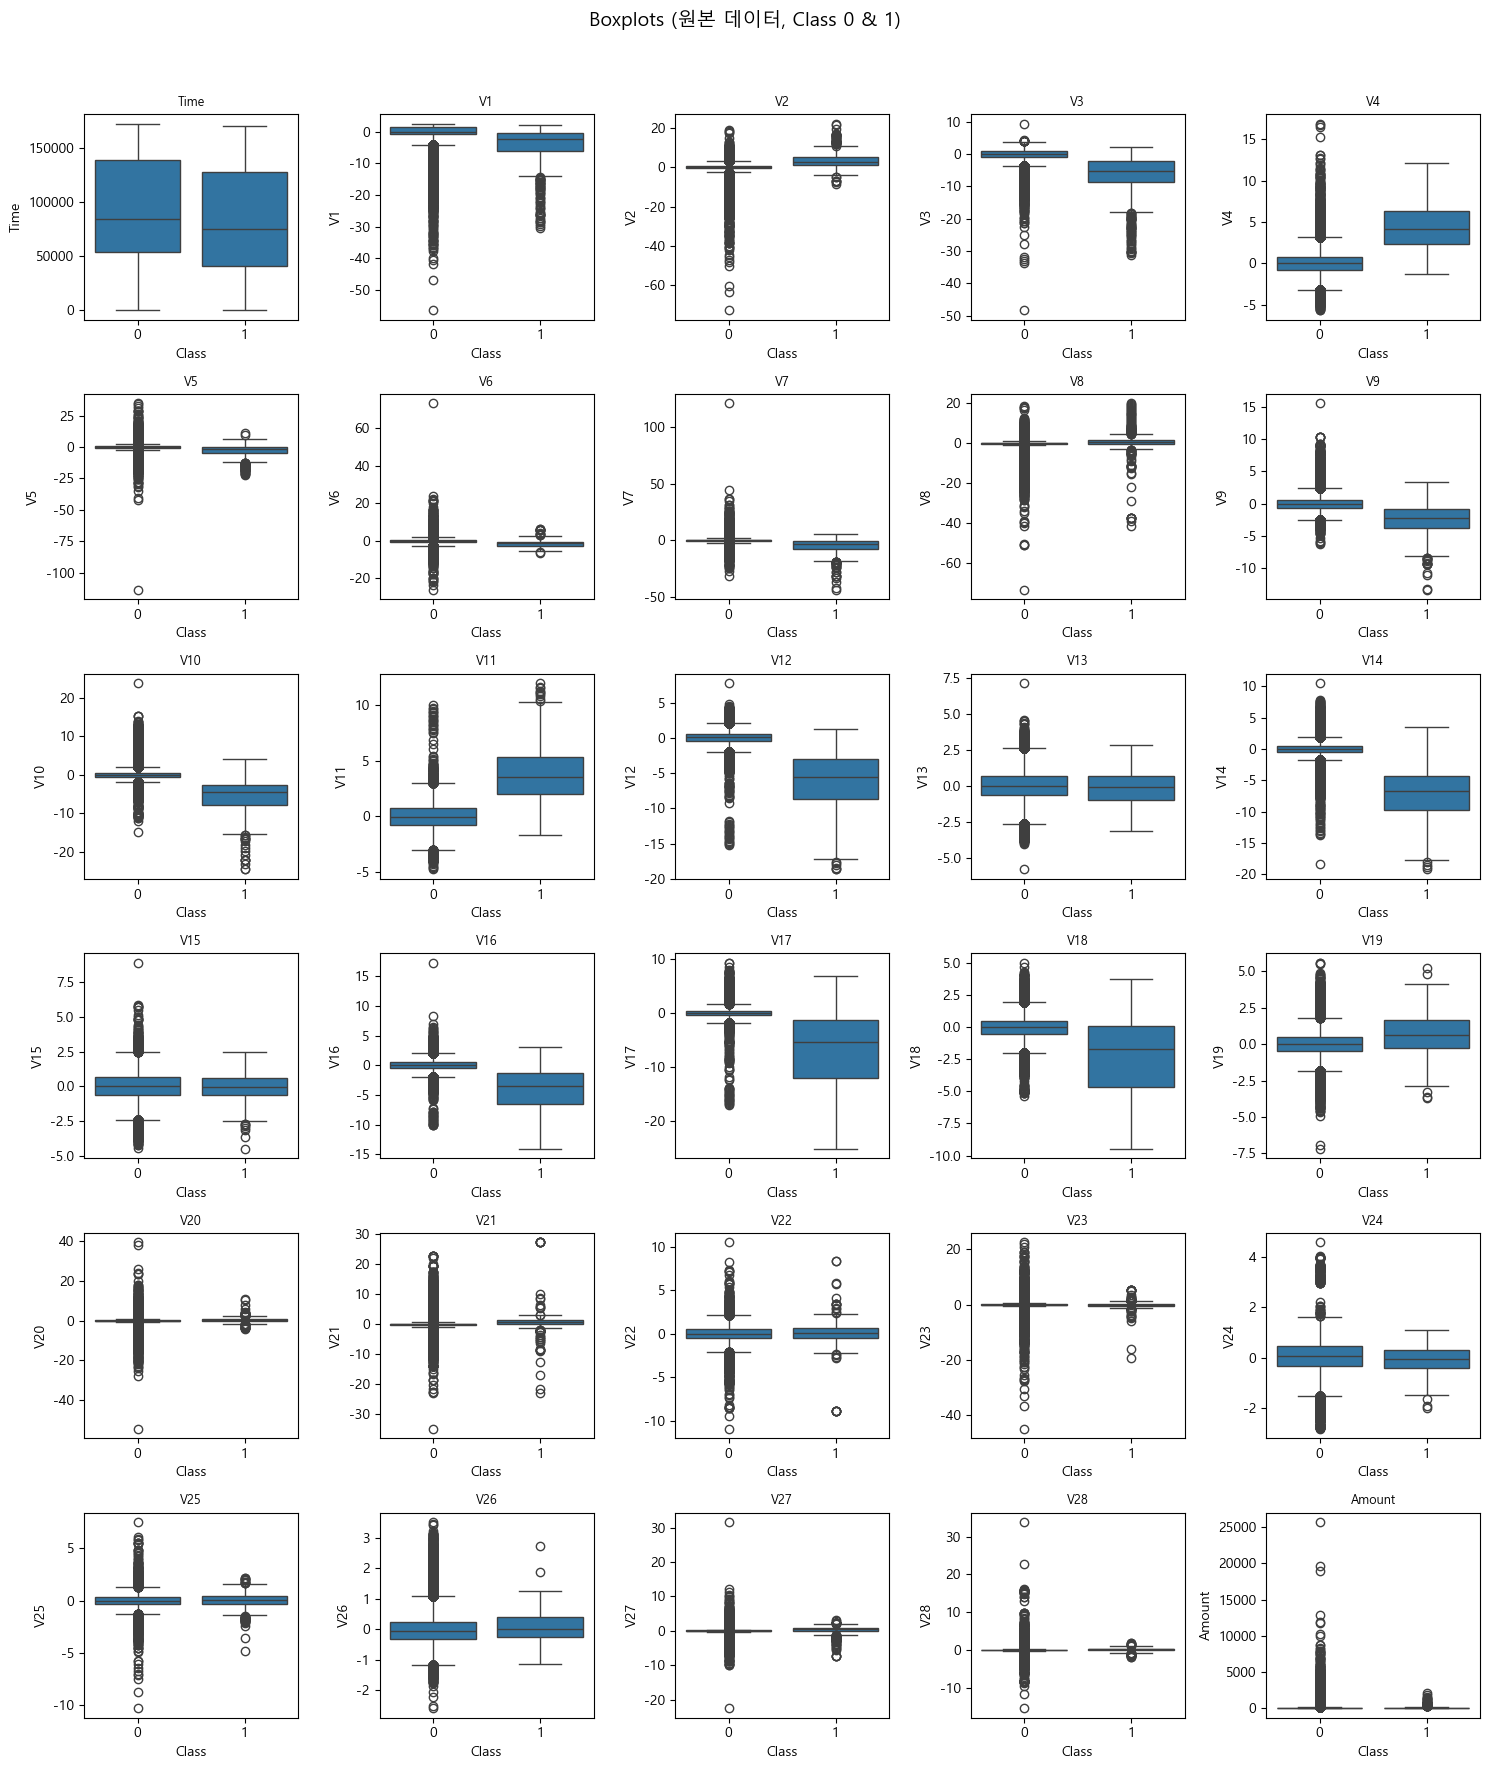

In [96]:
# 1) class=0,1 전부 (원본)
# 원본 df 기준 피처 목록 (Class만 제외)
feature_cols_all_raw = [c for c in df.columns if c != 'Class']

plot_box_grid_all(
    df=df,
    feature_cols=feature_cols_all_raw,
    title='Boxplots (원본 데이터, Class 0 & 1)'
)

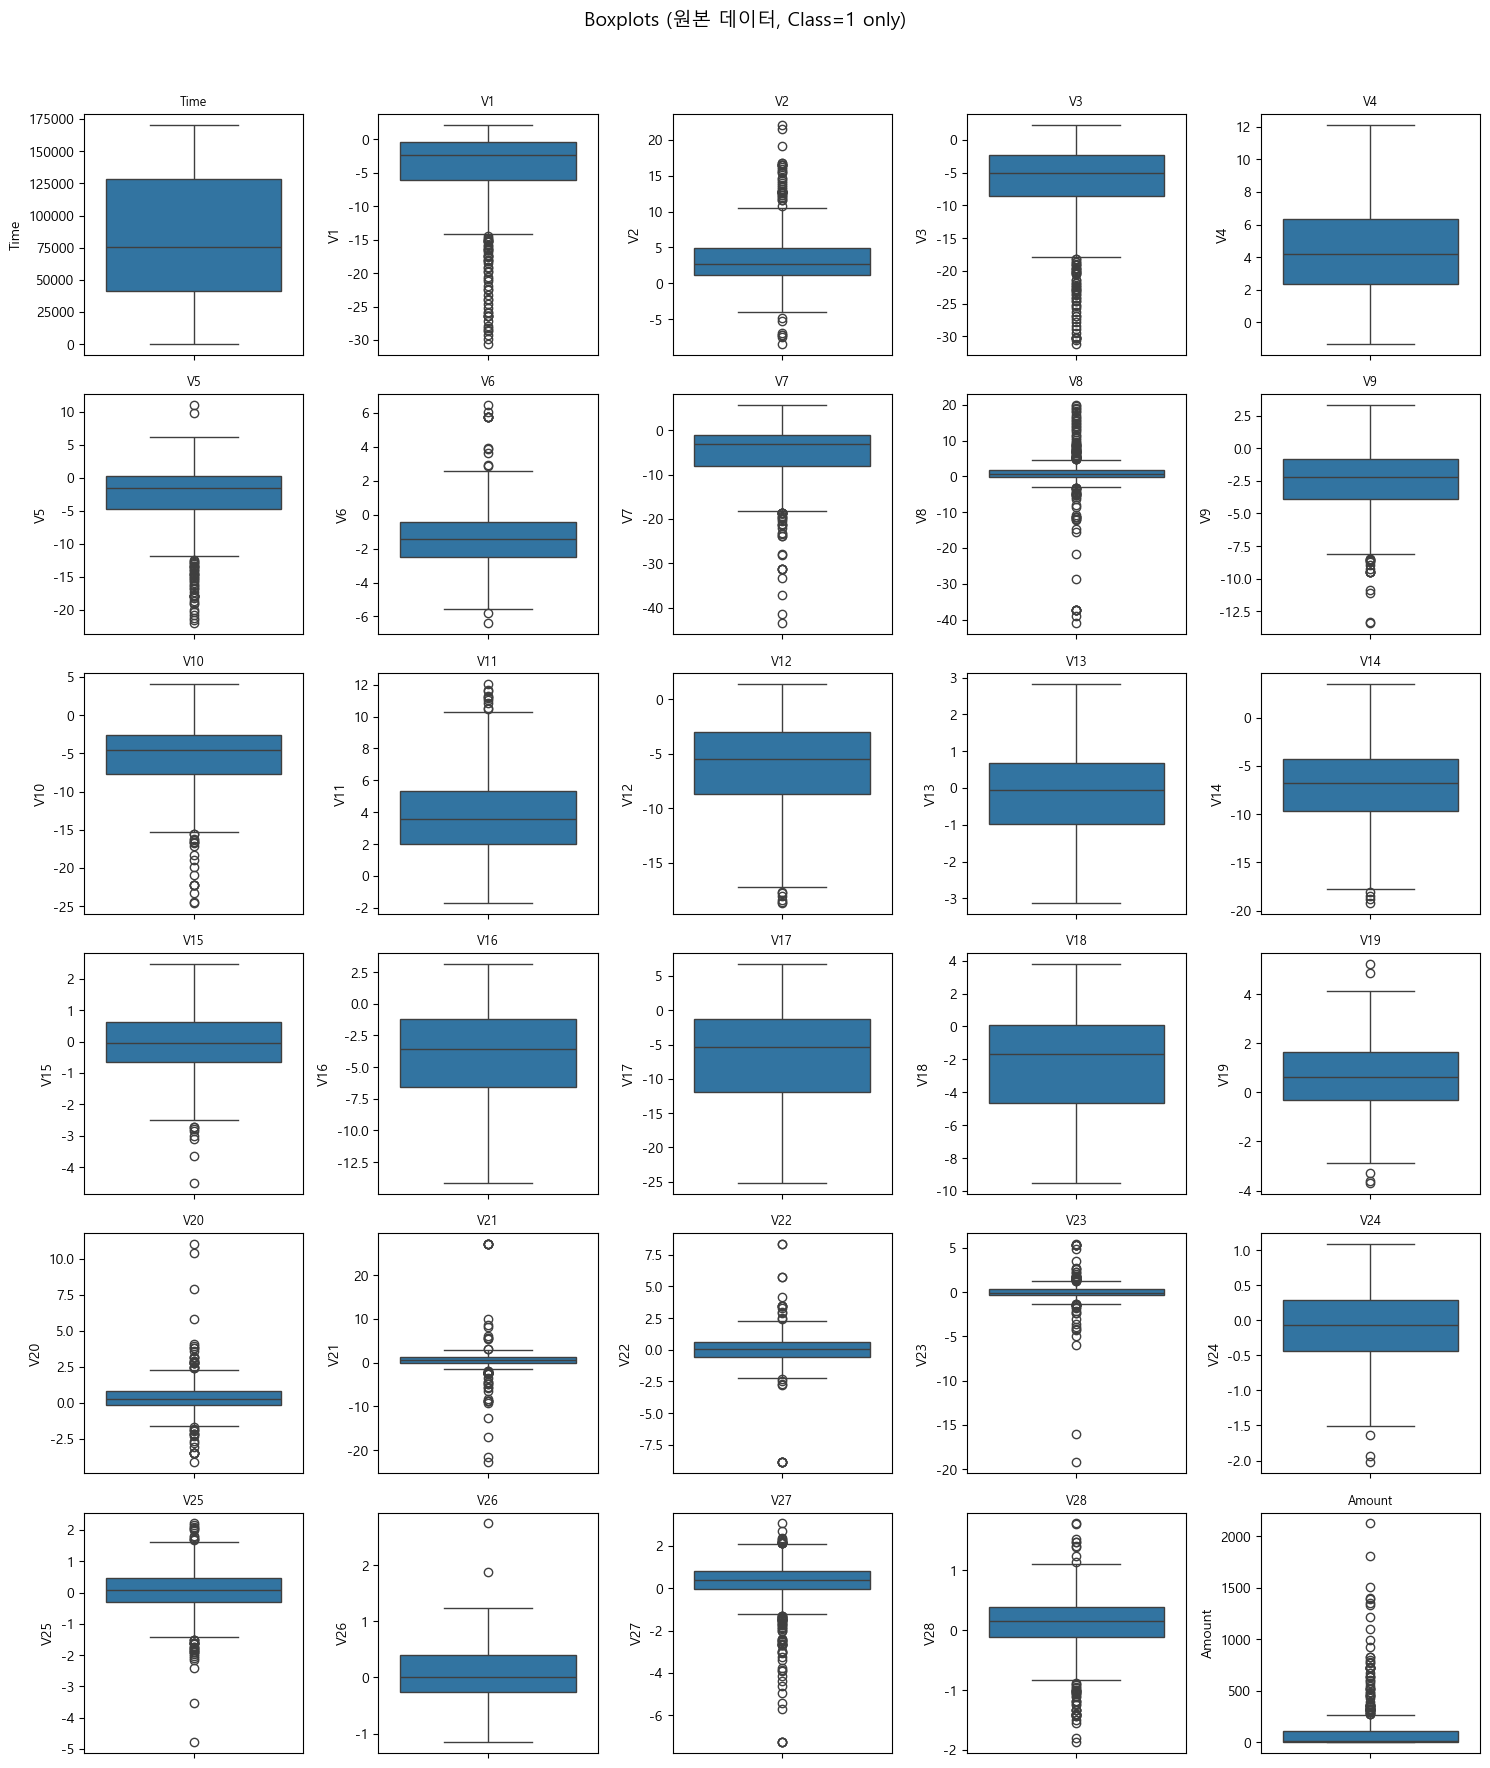

In [97]:
# 2) class=1만 (원본)
df_fraud_raw = df[df['Class'] == 1].copy()

plot_box_grid_fraud(
    df=df_fraud_raw,
    feature_cols=feature_cols_all_raw,  # Class 빼고 모두
    title='Boxplots (원본 데이터, Class=1 only)'
)

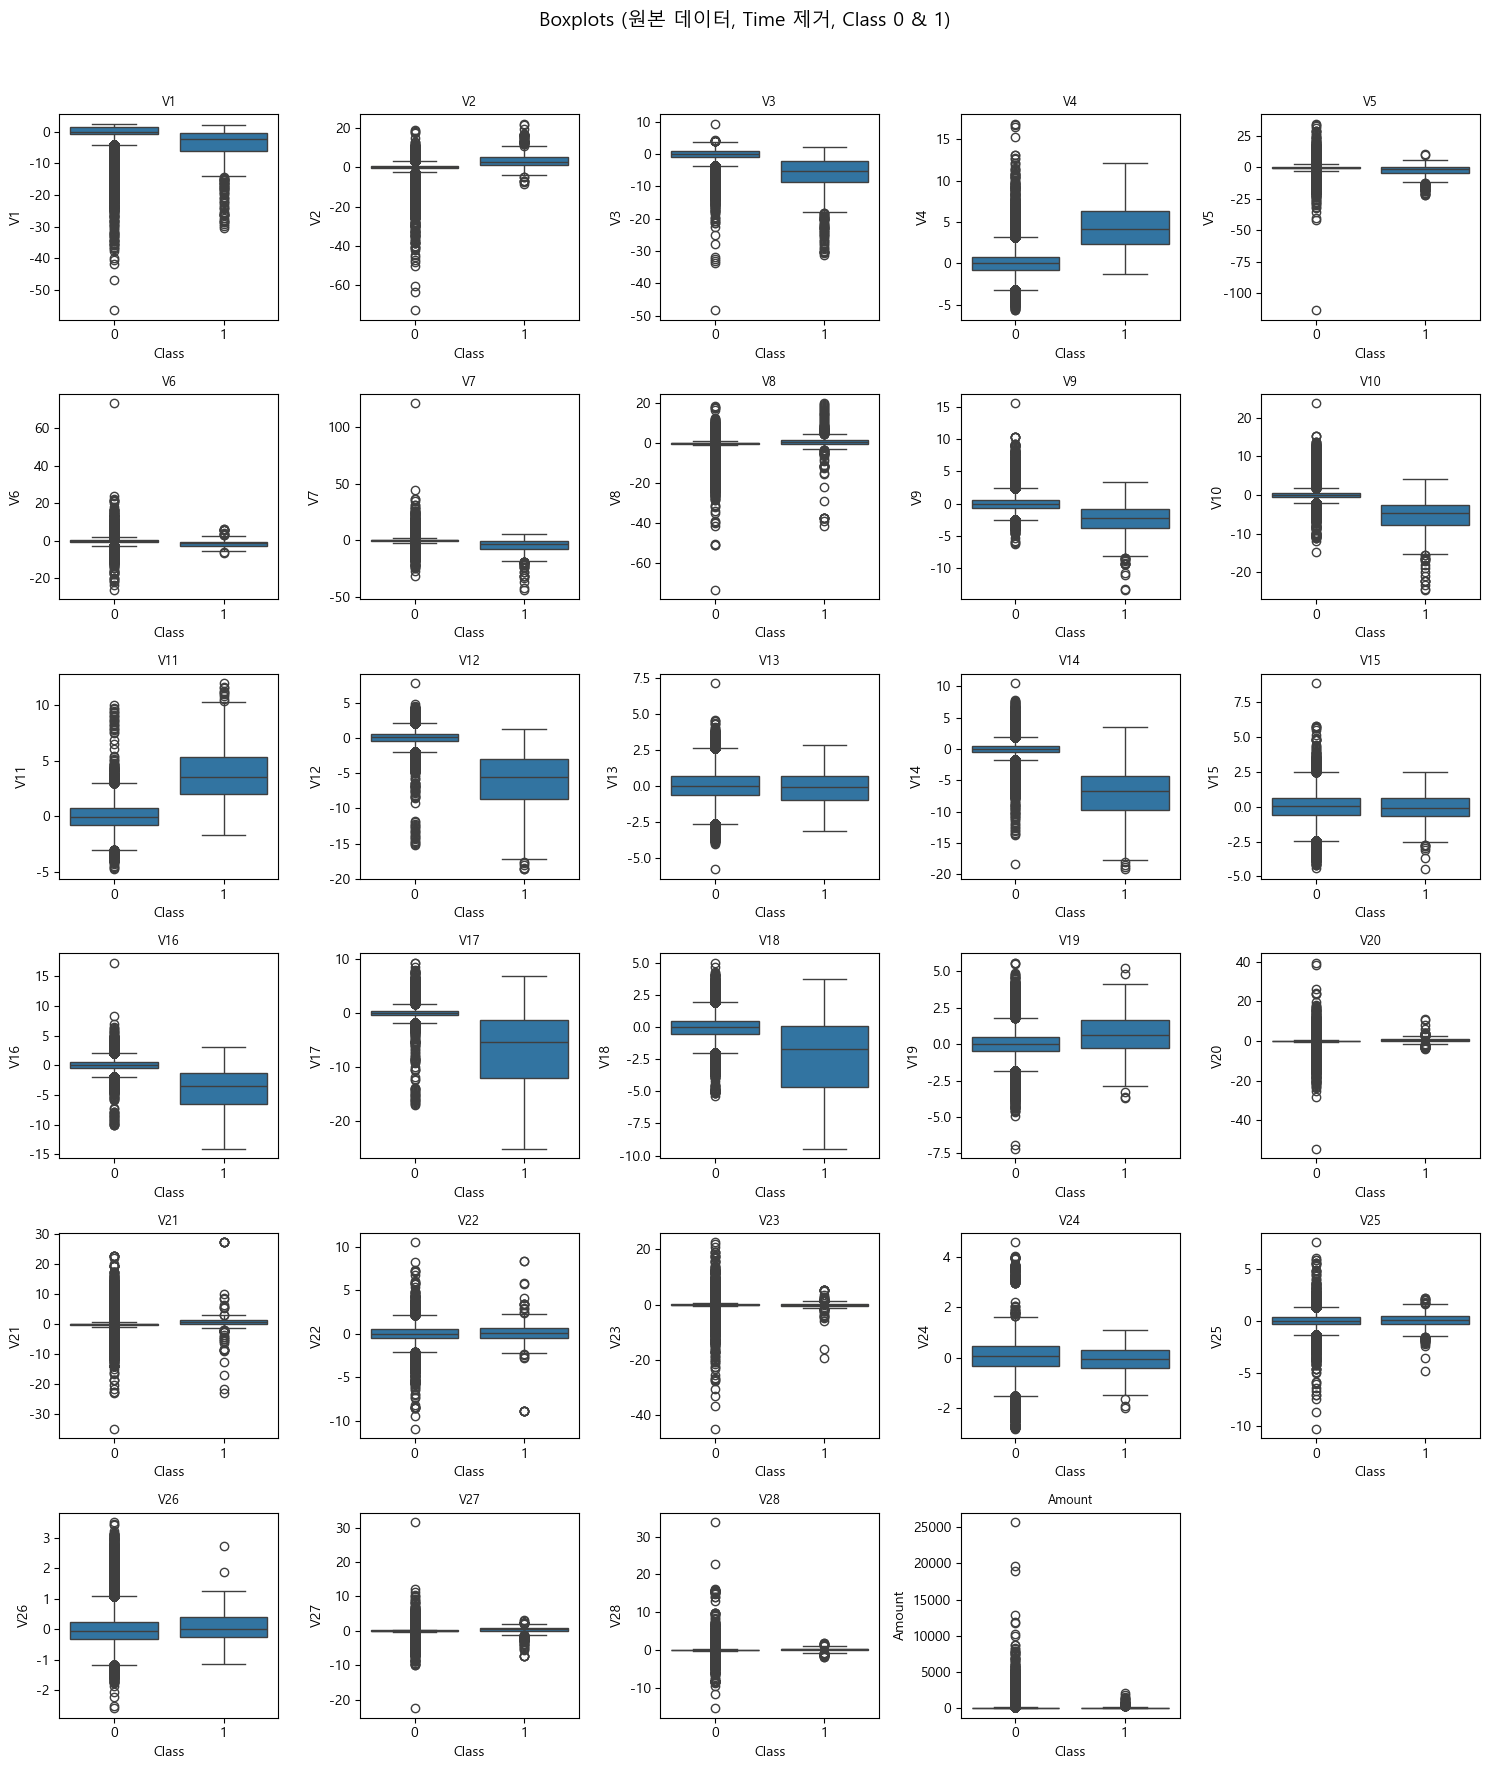

In [98]:
# 3) time이 제거된 버전 (원본 기준)

feature_cols_no_time_raw = [
    c for c in df.columns
    if c not in ['Class', 'Time']
]

plot_box_grid_all(
    df=df,
    feature_cols=feature_cols_no_time_raw,
    title='Boxplots (원본 데이터, Time 제거, Class 0 & 1)'
)

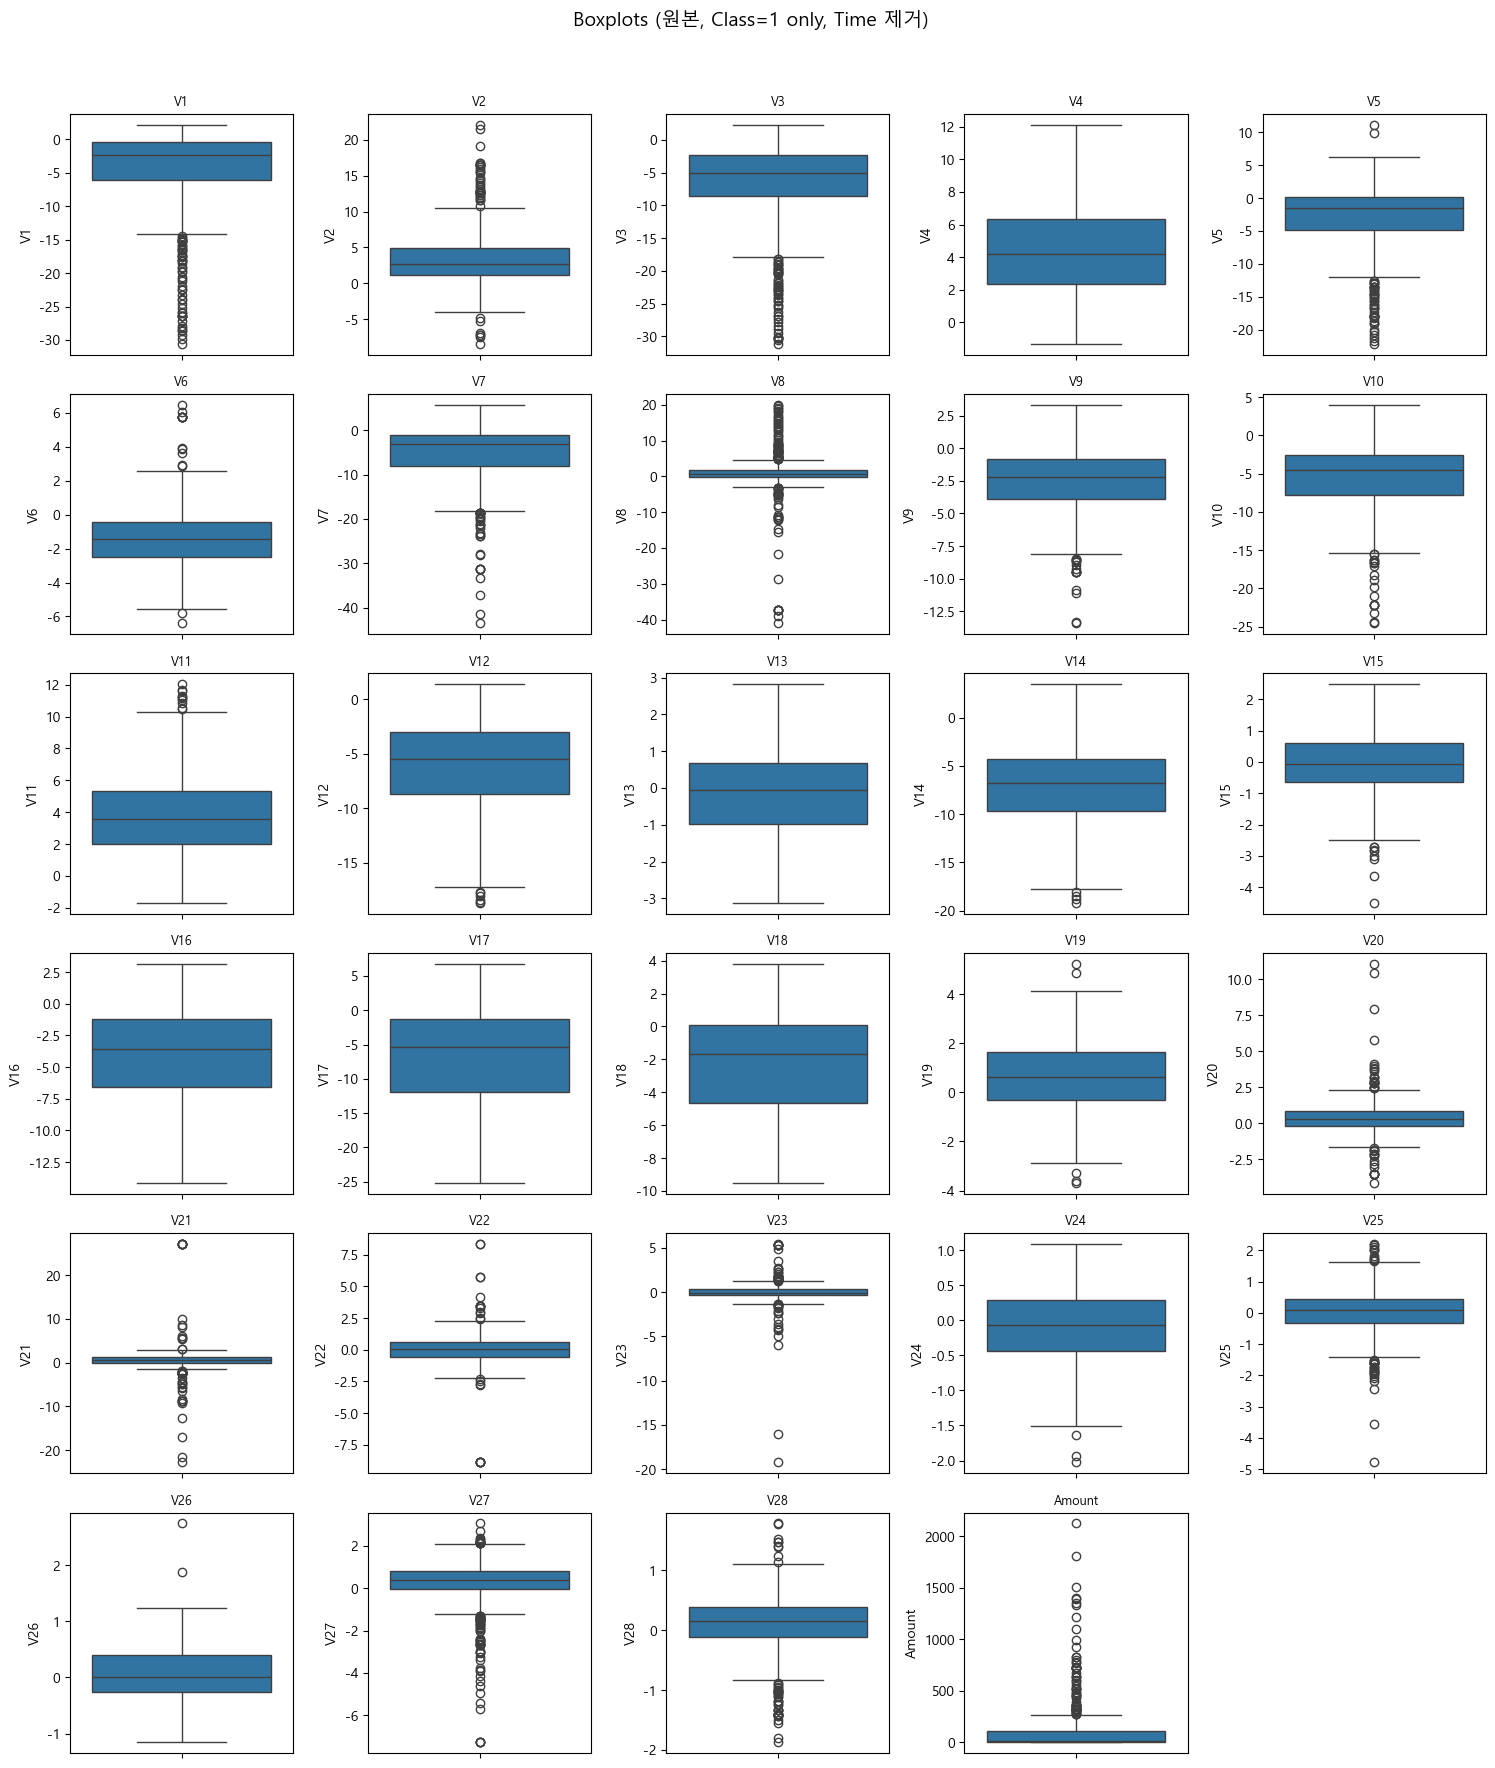

In [99]:
# Class=1만 + Time 제거한 피처 목록
df_fraud_raw = df[df['Class'] == 1].copy()

feature_cols_no_time_raw = [
    c for c in df.columns
    if c not in ['Class', 'Time']   # Class, Time 제거
]

def plot_box_grid_fraud(df_in, feature_cols, title, n_cols=5):
    """Class=1처럼 y축만 feature인 박스플롯을 그리기 위한 그리드 함수"""
    n_rows = math.ceil(len(feature_cols) / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(n_cols * 3, n_rows * 3))
    axes = axes.flatten()

    for i, col in enumerate(feature_cols):
        sns.boxplot(y=df_in[col], ax=axes[i])
        axes[i].set_title(col, fontsize=9)
        axes[i].set_xlabel('')

    # 남는 subplot 제거
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    fig.suptitle(title, fontsize=14)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

# Class=1 & Time 제거 박스플롯
plot_box_grid_fraud(
    df_in=df_fraud_raw,
    feature_cols=feature_cols_no_time_raw,
    title='Boxplots (원본, Class=1 only, Time 제거)'
)

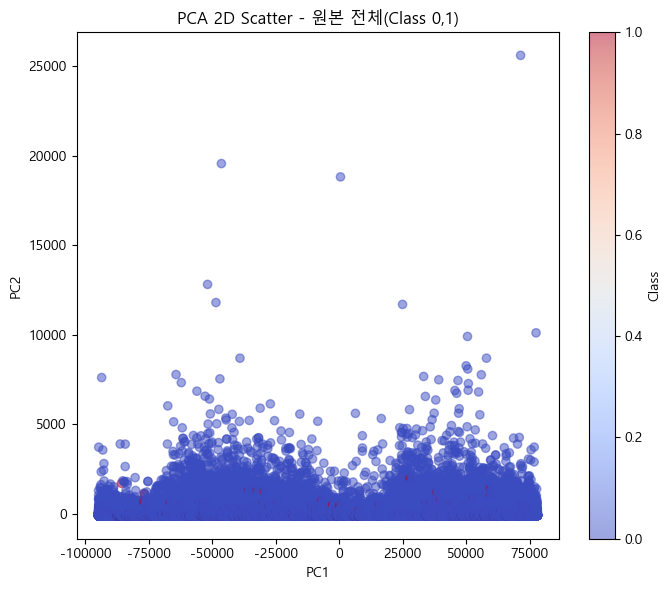

In [100]:
# 1) 전체 (원본)
X_all_raw = df[feature_cols_all_raw]   # Class 제외 모두
y_all_raw = df['Class']

pca_all_raw = PCA(n_components=2, random_state=42)
X_all_raw_2d = pca_all_raw.fit_transform(X_all_raw)

plt.figure(figsize=(7, 6))
scatter = plt.scatter(X_all_raw_2d[:, 0], X_all_raw_2d[:, 1],
                      c=y_all_raw, cmap='coolwarm', alpha=0.5)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA 2D Scatter - 원본 전체(Class 0,1)')
plt.colorbar(scatter, label='Class')
plt.tight_layout()
plt.show()

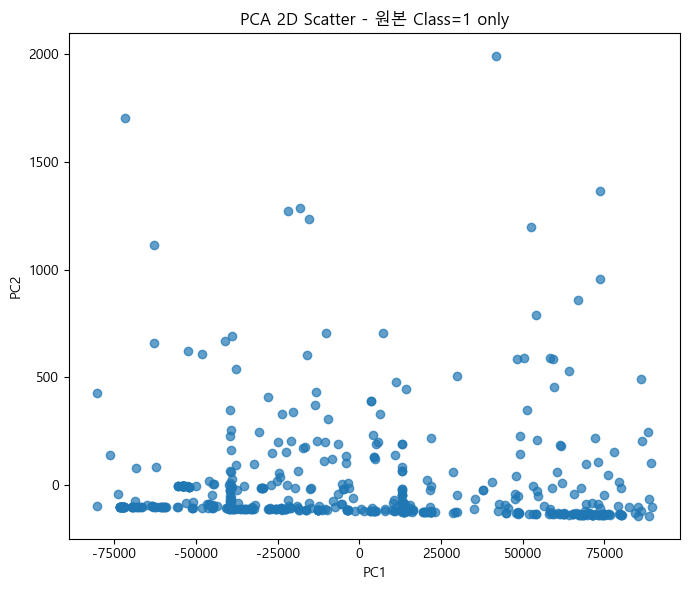

In [101]:
# 2) class=1만 (원본)
X_fraud_raw = df_fraud_raw[feature_cols_all_raw]

pca_fraud_raw = PCA(n_components=2, random_state=42)
X_fraud_raw_2d = pca_fraud_raw.fit_transform(X_fraud_raw)

plt.figure(figsize=(7, 6))
plt.scatter(X_fraud_raw_2d[:, 0], X_fraud_raw_2d[:, 1], alpha=0.7)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA 2D Scatter - 원본 Class=1 only')
plt.tight_layout()
plt.show()

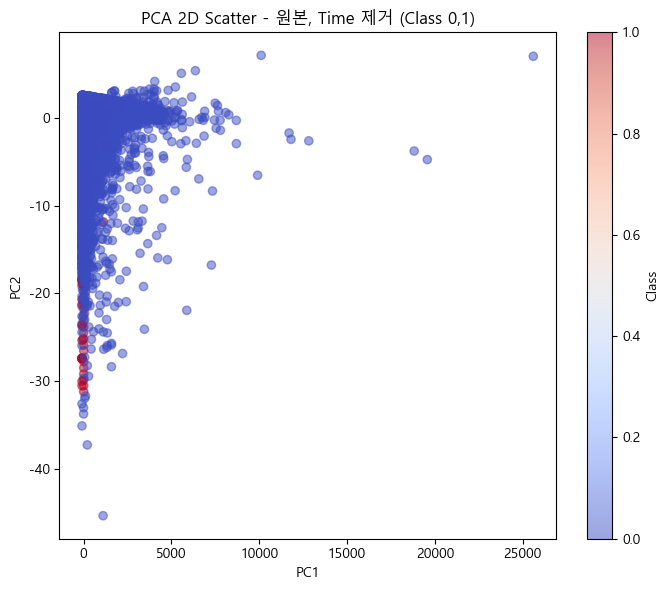

In [102]:
# 3) time 제거 버전 (원본 Time 제거)
X_no_time_raw = df[feature_cols_no_time_raw]
y_no_time_raw = df['Class']

pca_no_time_raw = PCA(n_components=2, random_state=42)
X_no_time_raw_2d = pca_no_time_raw.fit_transform(X_no_time_raw)

plt.figure(figsize=(7, 6))
scatter = plt.scatter(X_no_time_raw_2d[:, 0], X_no_time_raw_2d[:, 1],
                      c=y_no_time_raw, cmap='coolwarm', alpha=0.5)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA 2D Scatter - 원본, Time 제거 (Class 0,1)')
plt.colorbar(scatter, label='Class')
plt.tight_layout()
plt.show()

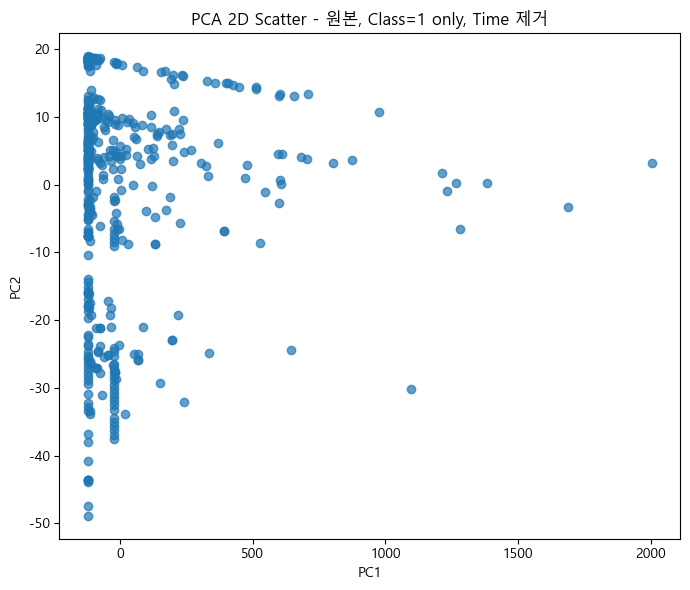

In [103]:
# PCA용 X (Class=1 & Time 제거)
X_fraud_no_time = df_fraud_raw[feature_cols_no_time_raw]

pca_fraud_no_time = PCA(n_components=2, random_state=42)
X_fraud_no_time_2d = pca_fraud_no_time.fit_transform(X_fraud_no_time)

plt.figure(figsize=(7, 6))
plt.scatter(X_fraud_no_time_2d[:, 0], X_fraud_no_time_2d[:, 1], alpha=0.7)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA 2D Scatter - 원본, Class=1 only, Time 제거')
plt.tight_layout()
plt.show()

In [104]:
# 학습/테스트 레이블 분포 확인
print(f'Learn data label value rate:')
# print(y_train.value_counts())
# print(y_train.shape) # (199364,)
print(y_train.value_counts() / y_train.shape[0] * 100) # 0: 99.827451, 1: 0.172549

print('Test data label value rate:')
# print(y_test.value_counts())
# print(y_test.shape) # (85443,)
print(y_test.value_counts() / y_test.shape[0] * 100)  # 0: 99.826785, 1: 0.173215

# straify 를 줘서 비슷해졌지만 불균형 심함

Learn data label value rate:


NameError: name 'y_train' is not defined

In [ ]:
# 평가 함수
# import get_clf_eval as gce
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.metrics import precision_score, recall_score
from sklearn.metrics import f1_score, roc_auc_score

import warnings
warnings.filterwarnings('ignore')

def get_clf_eval(y_test, pred, pred_proba):
    confusion = confusion_matrix(y_test, pred)
    accuracy  = accuracy_score(y_test, pred)
    precision = precision_score(y_test, pred)
    recall    = recall_score(y_test, pred)
    f1        = f1_score(y_test, pred)
    # AUC
    roc_auc   = roc_auc_score(y_test, pred_proba)
    print('오차행렬: ')
    print(confusion)
    print(f'정확도: {accuracy:.4f}, 정밀도: {precision:.4f}, 재현율: {recall:.4f}, F1: {f1:.4f}, AUC: {roc_auc:.4f}')


In [ ]:
# 이진 분류 : LogisticRegression 사용
# 데이터 가공도 안하고 튜닝도 안한 상태임을 잊지 말자
from sklearn.linear_model import LogisticRegression

# 1 create object
lr_clf = LogisticRegression(max_iter=1000)

# 2 Learn(학습)
lr_clf.fit(X_train, y_train)

# 3 predict(예측값), predict_proba(예측 확률 구하기)
lr_pred       = lr_clf.predict(X_test)
lr_pred_proba = lr_clf.predict_proba(X_test)[:, 1]

# 4 evalutation(평가)
get_clf_eval(y_test, lr_pred, lr_pred_proba) # 정확도: 0.9992, 정밀도: 0.8598, 재현율: "0.6216", F1: 0.7216, AUC: 0.9735

오차행렬: 
[[85280    15]
 [   56    92]]
정확도: 0.9992, 정밀도: 0.8598, 재현율: 0.6216, F1: 0.7216, AUC: 0.9735


In [ ]:
# get_model_train_eval 생성 (난 get_clf_eval.py에 넣어 놨음)
def get_model_train_eval(model, ftr_train=None, ftr_test=None, tgt_train=None, tgt_test=None):
    '''
        model별 학습, 예측값, 예측확율 구하기
        get_model_train_eval(lr_clf, X_train, X_test, y_train, y_test)
    '''
    model.fit(ftr_train, tgt_train)
    pred       = model.predict(ftr_test)
    pred_proba = model.predict_proba(ftr_test)[:, 1] # Positive인 확률만 가져오기

    get_clf_eval(tgt_test, pred, pred_proba)

In [ ]:
from lightgbm import LGBMClassifier

lgbm_clf = LGBMClassifier(
  n_estimators       = 1000,
  num_leaves         = 64,
  n_jobs             = -1, # 병렬처리
  boost_from_average = False,
  verbosity          = -1
)

get_model_train_eval(
  lgbm_clf,
  ftr_train = X_train,
  ftr_test  = X_test,
  tgt_train = y_train,
  tgt_test  = y_test
)
# 정확도: 0.9995, 정밀도: 0.9573, 재현율: "0.7568", F1: 0.8453, AUC: 0.9790

오차행렬: 
[[85290     5]
 [   25   121]]
정확도: 0.9996, 정밀도: 0.9603, 재현율: 0.8288, F1: 0.8897, AUC: 0.9780


In [ ]:
# 정규분호 확인 : 왜도, 첨도
# 왜도(skew) : 데이터의 비대칭성을 확인할 때 => 했는데 비대칭이면 log변환 필요,
#              StandardScaler 는 정규분포로 바뀌는 게 아니라 0에 가깝게 스케일링'만' 한 거임
# 첨도(kurtosis) : 중앙 부분이 얼마자 뽀족한지 나타내는 것
# 양의 첨도 : 꼬리가 두껍고, 중앙 부분이 뽀족한 경우, 극단값(이상치)이 자주 발생
# ㄴ 극단값 처리 피요, 적절한 모델 선택 필요
# 음의 첨도 : 꼬리가 얇고, 중앙 부분이 평평한 경우, 극단값이 적게 발생
# 중간 첨도(0에 가까운 경우) : 정규 분포를 따른다
# 정규분포란 왜도와 첨도가 0에 가까운 경우를 이야기 한다
# q-qplot으로도 시각화 가능

from scipy.stats import skew, kurtosis # 함수
print(skew(df['Amount']))     # 16.97763503663313
print(kurtosis(df['Amount'])) # 845.0777883188744 => 양의 첨도 : 극단값이 많을 듯

16.97763503663313
845.0777883188744


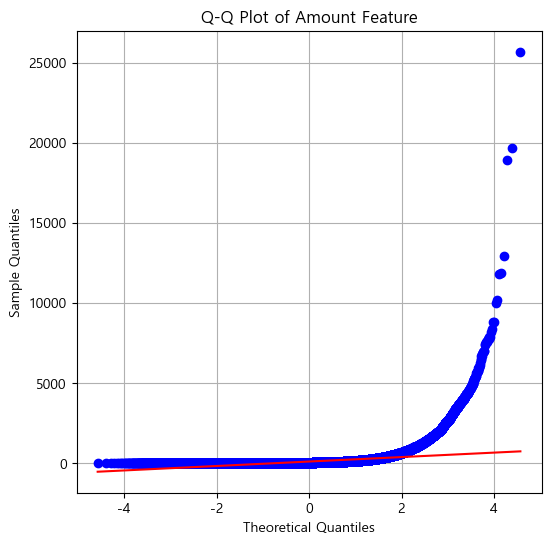

In [ ]:
# q-qplot 돌려보기 (self testing)
import matplotlib.pyplot as plt
import scipy.stats as stats

# Q-Q plot 그리기
plt.figure(figsize=(6, 6))
stats.probplot(df['Amount'], dist="norm", plot=plt)
plt.title('Q-Q Plot of Amount Feature')
plt.xlabel('Theoretical Quantiles')
plt.ylabel('Sample Quantiles')
plt.grid(True)
plt.show()

In [ ]:
# 진짜 정규분포로 바뀌는 지 확인해보자!
from sklearn.preprocessing import StandardScaler

# 기존 데이터(Amount)만 가지고 평균, 표준 편차, 왜도, 첨도 구하기
avg_amount = df['Amount'].mean()
std_amount = df['Amount'].std()

print(f"- mean : {avg_amount}\n- std_amount: {std_amount}")
print(f"- skew : {skew(df['Amount'])}\n- kurtosis: {kurtosis(df['Amount'])}")
print('='*50)
# scaling
scaler  = StandardScaler()
n_amount = scaler.fit_transform(df['Amount'].values.reshape(-1,1))
print(f'Mean of after normalization : {n_amount.mean()}')
print(f'Std of after normalization : {n_amount.std()}')
print(f'Skew of after normalization : {skew(n_amount)}')
print(f'Kurtosis of after normalization : {kurtosis(n_amount)}')
# 책이 잘못됐다. StandardScaler()는 scaling만 한 거고 정규분포로 변환 된거 아니다잉~


- mean : 88.34961925093134
- std_amount: 250.12010924018855
- skew : 16.97763503663313
- kurtosis: 845.0777883188744
Mean of after normalization : -3.6723778103728753e-17
Std of after normalization : 1.0
Skew of after normalization : [16.97763504]
Kurtosis of after normalization : [845.07778832]


In [ ]:
# get_preprocssed_df 함수 변경
def get_preprocssed_df(df=None):
    df_copy = df.copy()

    scaler = StandardScaler()
    amount_n = scaler.fit_transform(df_copy['Amount'].values.reshape(-1, 1))
    df_copy.insert(0, 'Amount_Scaled', amount_n) # 0번째에 추가해라

    df_copy.drop(['Time','Amount'], axis=1, inplace=True)
    return df_copy

In [ ]:
X_train, X_test, y_train, y_test = get_train_test_dataset(df)

lf_clf = LogisticRegression(max_iter=1000)
get_model_train_eval(
  lf_clf,
  ftr_train = X_train,
  ftr_test  = X_test,
  tgt_train = y_train,
  tgt_test  = y_test
)
# LF(Scaled) - 정확도: 0.9992, 정밀도: 0.8692, 재현율: 0.6284, F1: 0.7294, AUC: 0.9706

lgbm_clf = LGBMClassifier(
  n_estimators       = 1000,
  num_leaves         = 64,
  n_jobs             = -1, # 병렬처리
  boost_from_average = False,
  verbosity          = -1
)

get_model_train_eval(
  lgbm_clf,
  ftr_train = X_train,
  ftr_test  = X_test,
  tgt_train = y_train,
  tgt_test  = y_test
)
# LGBM(Scaled) 정확도: 0.9995, 정밀도: 0.9569, 재현율: 0.7500, F1: 0.8409, AUC: 0.9779

오차행렬: 
[[85280    15]
 [   48    98]]
정확도: 0.9993, 정밀도: 0.8673, 재현율: 0.6712, F1: 0.7568, AUC: 0.9725
오차행렬: 
[[85290     5]
 [   25   121]]
정확도: 0.9996, 정밀도: 0.9603, 재현율: 0.8288, F1: 0.8897, AUC: 0.9780


In [ ]:
# get_preprocssed_df 함수 2차 변경
def get_preprocssed_df(df=None):
    df_copy = df.copy()
    # log1p = log 1 plus : x가 0일때 y가 -inf(=무한대)로 발산해버리니까 +1 하라! - 부분은 나오지 않게
    # log함수에서 x가 0~1 사이에 있으면 안된다, 무한대+1, 무한대-1 가 모두 무한대가 되버려서 이 후 계산이 무의미해진다
    amount_n = np.log1p(df_copy['Amount'])
    df_copy.insert(0, 'Amount_Scaled', amount_n)
    df_copy.drop(['Time','Amount'], axis=1, inplace=True)
    return df_copy

# - 머신러닝에서 log1p()는 데이터 스케일링이나 왜도(skewness) 보정을 위해 자주 사용됩니다.
# - 특히 **금액(Amount)**처럼 0 이상의 양수 값을 다룰 때, log1p()는 0도 처리 가능하므로 안전하게 로그 변환할 수 있어요.
# - 일반적인 np.log(x)는 x=0에서 오류가 나지만, log1p(0)은 0을 반환합니다.


In [ ]:
X_train, X_test, y_train, y_test = get_train_test_dataset(df)

lf_clf = LogisticRegression(max_iter=1000)
get_model_train_eval(
  lf_clf,
  ftr_train = X_train,
  ftr_test  = X_test,
  tgt_train = y_train,
  tgt_test  = y_test
)
# LF(log) - 정확도: 0.9992, 정밀도: 0.8725, 재현율: 0.6014, F1: 0.7120, AUC: 0.9734 => 회귀라서 큰값이 의미가 없다

lgbm_clf = LGBMClassifier(
  n_estimators       = 1000,
  num_leaves         = 64,
  n_jobs             = -1, # 병렬처리
  boost_from_average = False,
  verbosity          = -1
)

get_model_train_eval(
  lgbm_clf,
  ftr_train = X_train,
  ftr_test  = X_test,
  tgt_train = y_train,
  tgt_test  = y_test
)
# LGBM(log) 정확도: 0.9995, 정밀도: 0.9576, 재현율: 0.7635, F1: 0.8496, AUC: 0.9796

오차행렬: 
[[85282    13]
 [   59    89]]
정확도: 0.9992, 정밀도: 0.8725, 재현율: 0.6014, F1: 0.7120, AUC: 0.9734
[LightGBM] [Info] Number of positive: 344, number of negative: 199020
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.012466 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7395
[LightGBM] [Info] Number of data points in the train set: 199364, number of used features: 29
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Wa

In [ ]:
# 이상치 데이터 제거 후 모델 학습/예측/평가 (원본 책 4장 p108)
# 이상치 데이터(Outlier)는 전체 데이터의 "패턴"에서 벗어난 이상 값을 가진 데이터이며,
# 아웃라이어라고도 불립니다. 이상치로 인해 머신러닝 모델의 성능에 영향을 받는 경우가 발생하기 쉽습니다.
# (Tree 계열은 덜 민감하고 회귀계열(잔차)은 민감함)
# 이상치를 찾는 방법은 여러 가지가 있지만, 이 중에서 IQR(Inter Quantile Range) 방식을 적용해 보겠다
# IQR은 사분위(Quantile) 값의 편차를 이용하는 기법으로 흔히 박스 플롯(Box Plot) 방식으로 시각화할 수 있다. Q1 ~ Q3 범위의 값: q3-q1값

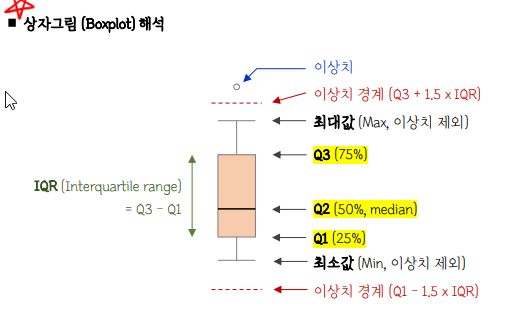

In [ ]:
# 매우 많은 피처가 있을 경우 이들 중 결정값(즉 레이블)과 가장 상관성이 높은 피처들을 위주로 이상치를 검출하는 것이 좋다!! 결정값과 상관성이 높지 않은 피처들의 경우는 이상치를 제거하더라도 크게 성능 향상 에 기여하지 않는다
# DataFrame의 corr()을 이용해 각 피처별로 상관도를 구한 뒤 Saeborn의 heatmap을 통해 시각화해 보겠다. 컬러가 진할 수록 관계가 높다

<Axes: >

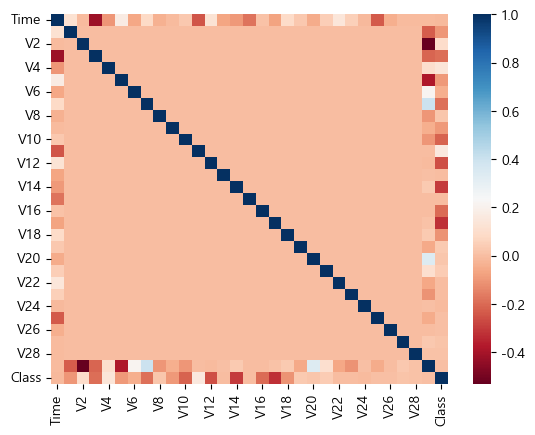

In [ ]:
# 이상치 제거
import seaborn as sns

corr = card_df.corr()
sns.heatmap(corr, cmap='RdBu') # 과제할때 V2~V17까지 다 챙겨봐라

In [ ]:
corr['Class'].sort_values(ascending=True)[:10] #.head(10), - + 는 따질 필요없이 크기만 봐야 한다, 과제시 ~V7까지 확인해봐라

V17   -0.326481
V14   -0.302544
V12   -0.260593
V10   -0.216883
V16   -0.196539
V3    -0.192961
V7    -0.187257
V18   -0.111485
V1    -0.101347
V9    -0.097733
Name: Class, dtype: float64

In [ ]:
# method by 한창숙
print(corr['Class'].drop('Class').abs().sort_values(ascending=False)[:10])

V17    0.326481
V14    0.302544
V12    0.260593
V10    0.216883
V16    0.196539
V3     0.192961
V7     0.187257
V11    0.154876
V4     0.133447
V18    0.111485
Name: Class, dtype: float64


In [ ]:
# 이상치 검출 방식 : IQR, DBSCAN(비지도 학습), Isolation Forest(DataSet이 많을때 좋음, 대용량, 고차원(피처가 많은)), Z-score(평균이 들어간다~ 그래서 문젤껄?)
#                    => 장점, 문제점등을 파악해서 레포트해라

# fraud = card_df[card_df['Class'] == 1]['V14'] # Series 다
# # print(fraud) # 492개
# # 25%, 75% 위치에 있는 값 구한다
# q_25 = np.percentile(fraud.values, 25) # ndarray로 넣어줘야해서 froud.values 로 뽑은 거임
# q_75 = np.percentile(fraud.values, 75)
# # print(q_25, q_75, q_75-q_25)
# iqr = q_75 - q_25
# print(iqr)
# iqr_weight   = iqr*1.5
# lowest_val   = q_25 - iqr_weight
# highest_val = q_75 + iqr_weight
# print(lowest_val, highest_val)


# Outlier가 어디에 있는지 추출하는 함수
def get_outlier(df=None, column=None, weight=1.5): # weight=1.5 고정은 아니다! 존 튜키(John Tukey)
    # 사기인 것의 컬럼 추출, column = 'V14' 중 사기인 것만 이상치 추출
    # 원래는 outlier라고 주는게 맞을 듯. Class==1인 경우만 따지고 있으니 담에 아닌 경우도 확인해봐라
    fraud = df[df['Class'] == 1][column] # Series 다
    # 25%, 75% 위치에 있는 값 구한다
    q_25 = np.percentile(fraud.values, 25) # np.percentile()은 ndarray로 넣어줘야해서 froud.values 로 뽑은 거임
    q_75 = np.percentile(fraud.values, 75)
    iqr  = q_75 - q_25
    iqr_weight = iqr * weight
    lowest_val  = q_25 - iqr_weight
    highest_val = q_75 + iqr_weight

    # 최대값 보다 크거나(or => |), 최소값 보다 작은 값을 아웃라이어로 설정하고 Series니까 index 반환 가능
    outlier_index = fraud[(fraud < lowest_val) | (fraud > highest_val)].index
    return outlier_index


In [ ]:
outlier_index = get_outlier(df=card_df, column='V14')
print(outlier_index)
print(card_df['V14'].iloc[outlier_index])

Index([8296, 8615, 9035, 9252], dtype='int64')
8296   -19.214325
8615   -18.822087
9035   -18.493773
9252   -18.049998
Name: V14, dtype: float64


In [ ]:
# 이상치 지우고
def get_preprocssed_df(df=None):
  df_copy = df.copy()
  # 로그 변환
  amount_n = np.log1p(df_copy['Amount'])
  df_copy.insert(0, 'Amount_Scaled', amount_n)
  df_copy.drop(['Time', 'Amount'], axis=1, inplace=True)
  # 이상치 제거
  outlier_index = get_outlier(df=df_copy, column='V14')
  df_copy.drop(outlier_index, axis=0, inplace=True)
  return df_copy


In [ ]:
X_train, X_test, y_train, y_test = get_train_test_dataset(card_df)

print('#### 로지스틱 회귀 예측 성능')
get_model_train_eval(lf_clf, X_train, X_test, y_train, y_test)
# 정확도: 0.9993, 정밀도: 0.8673, 재현율: 0.6712, F1: 0.7568, AUC: 0.9725

print('#### LightGBM 회귀 예측 성능')
get_model_train_eval(lgbm_clf, X_train, X_test, y_train, y_test)
# 정확도: 0.9996, 정밀도: 0.9603, 재현율: 0.8288, F1: 0.8897, AUC: 0.9780

#### 로지스틱 회귀 예측 성능
오차행렬: 
[[85280    15]
 [   48    98]]
정확도: 0.9993, 정밀도: 0.8673, 재현율: 0.6712, F1: 0.7568, AUC: 0.9725
#### LightGBM 회귀 예측 성능
[LightGBM] [Info] Number of positive: 342, number of negative: 199020
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.012257 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7395
[LightGBM] [Info] Number of data points in the train set: 199362, number of used features: 29
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with pos

In [ ]:
# SMOTE 오버 샘플링 적용 후 모델 학습/예측/평가
# 이번에는 SMOTE 기법으로 오버 샘플링을 적용한 뒤 로지스틱 회귀와 LightGBM 모델의 예측 성능을 평가해 보겠다.
# 먼저 SMOTE는 앞에서 설치한 imbalanced-learn 패키지의 SMOTE 클래스를 이용해 간단하게 구현이 가능.
# SMOTE를 적용할 때는 "반드시 학습 데이터 세트만" 오버 샘플링을 해야 합니다.
# 검증 데이터 세트나 테스트 데이터 세트를 오버 샘플링할 경우 결국은 원본 데이터 세트가 아닌 데이터 세트에서 검증 또는 테스트를 수행하기 때문에
# 올바른 검증/테스트가 될 수 없습니다.
# 앞 예제에서 생성한 학습 피처/레이블 데이터를 SMOTE 객체의 fit_resample() 메서드를 이용해 증식한 뒤 데이터를 증식 전과 비교해 보겠다.
# @ conda-prompt 에서
# conda activate ml_dev
# conda install -c conda-forge imbalanced-learn


In [ ]:
# 오버 샘플링
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=0)

X_train_over, y_train_over = smote.fit_resample(X_train, y_train) # data & label 반환
print(X_train.shape, y_train.shape)           #(199362, 29) (199362,)
print(X_train_over.shape, y_train_over.shape) #(398040, 29) (398040,)

(199362, 29) (199362,)
(398040, 29) (398040,)


In [ ]:
print(y_train.value_counts())
print(y_train_over.value_counts()) # 5 vs 5 로

Class
0    199020
1       342
Name: count, dtype: int64
Class
0    199020
1    199020
Name: count, dtype: int64


In [ ]:
print('### 오버샘플링 후 LR : ') # log함수써서 더 그럼. 회귀인데
get_model_train_eval(lr_clf, X_train_over, X_test, y_train_over, y_test)
# 정확도: 0.9722, 정밀도: 0.0541, 재현율: 0.9247, F1: 0.1022, AUC: 0.9736

### 오버샘플링 후 LR : 
오차행렬: 
[[82933  2362]
 [   11   135]]
정확도: 0.9722, 정밀도: 0.0541, 재현율: 0.9247, F1: 0.1022, AUC: 0.9736


In [ ]:
print('### 오버샘플링 후 LGBM : ')
get_model_train_eval(lgbm_clf, X_train_over, X_test, y_train_over, y_test)
# 정확도: 0.9996, 정밀도: 0.9118, 재현율: 0.8493, F1: 0.8794, AUC: 0.9814

### 오버샘플링 후 LGBM : 
[LightGBM] [Info] Number of positive: 199020, number of negative: 199020
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.025950 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7395
[LightGBM] [Info] Number of data points in the train set: 398040, number of used features: 29
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warni

In [ ]:
# XGBoost 추가하고 HyperOpt 추가하고, 이상치 컬럼 추가하고